# Ext Fig. 3: Individual place field analyses

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import sys
import os
import pickle
import dill
import numpy as np
import scipy as sp
import pandas as pd
import warnings
import copy
import phase_precession.core as ppcore
from datetime import datetime

from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
sns.set_style("white")

from reward_relative import behavior as behav
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import regression
    
import TwoPUtils

import sklearn
from sklearn.impute import KNNImputer


save_figures = False

In [2]:
from reward_relative.path_dict_firebird import path_dictionary as path_dict

In [3]:
path_dict

{'preprocessed_root': '/data/2P',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2P/VR_Data',
 'git_repo_root': '/home/mari/local_repos/2p_repos',
 'TwoPUtils': '/home/mari/local_repos/2p_repos/TwoPUtils',
 'home': '/home/mari',
 'fig_dir': '/data/2P/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2P/fig_scratch/Jun2025


## Load saved multiDayData

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multiDayData',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))

include_ans = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                     for day in exp_days])), 
                           key=len)

/data/2P/multiDayData/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


## Functions to assess cells with multiple fields

In [6]:
def find_first_n(a, n, window=5):
    
    ## James Priestley method of finding a formation lap
    ## from: https://github.com/james-priestley/ca1_novelty_analysis/blob/a04e357905cacc1efd75ec96ffcb6e293bb71ab9/platz/platz/util.py#L59

    for index, item in enumerate(a):
        if item:
            count = np.sum(a[index:index + window] > 0)
            if count >= n:
                return index

In [7]:
def find_sig_active_fields(sess,
                           trial_dict,
                           cell_ids=None,
                           smooth_for_field=True,
                           n_std=2,
                           n_trials_thr=6,
                           field_thr=0.2,
                           sigma=1,
                           speed_thr=2,
                           n_shuf=100):
    ''' 
    Find significantly active fields per cell

    This function does most of the heavy lifting for this notebook
    '''

    # Get the trial-by-trial activity, at speeds > speed_thr
    tm = TwoPUtils.spatial_analyses.trial_matrix(sess.timeseries['events'].T,
                                                 sess.vr_data['pos']._values,
                                                 sess.trial_start_inds,
                                                 sess.teleport_inds,
                                                 bin_size=10,
                                                 min_pos=0,
                                                 max_pos=450,
                                                 speed_thr=speed_thr,
                                                 speed=sess.vr_data['speed']._values
                                                 )

    field_dict_thresh = {'set 0': [],
                         'set 1': []
                         }

    # field detection before the switch
    trial_set0_mask = trial_dict['trial_set0']
    field_dict_thresh['set 0'] = spatial.field_from_thresh(tm[0][trial_set0_mask, :, :],
                                                           tm[-1],
                                                           cells=cell_ids,
                                                           prctile=field_thr,
                                                           smooth=smooth_for_field,
                                                           sigma=sigma)

    trial_set1_mask = np.zeros(trial_dict['trial_set1'].shape).astype(bool)
    trial_set1_mask[-30:] = True

    # field detection in the last 30 trials after the switch
    field_dict_thresh['set 1'] = spatial.field_from_thresh(tm[0][trial_set1_mask, :, :],
                                                           tm[-1],
                                                           cells=cell_ids,
                                                           prctile=field_thr,
                                                           smooth=smooth_for_field,
                                                           sigma=sigma)

    # field detection using all post-switch trials (typically wider boundaries)
    full_set1_field = spatial.field_from_thresh(tm[0][trial_dict['trial_set1'], :, :],
                                                tm[-1],
                                                cells=cell_ids,
                                                prctile=field_thr,
                                                smooth=smooth_for_field,
                                                sigma=sigma)

    rzone_pos, _ = behav.get_reward_zones(sess)
    rzone = {'0': rzone_pos[0][0],
             '1': rzone_pos[-1][0]
             }

    trial_mat = np.copy(tm[0])
    if smooth_for_field:
        trial_mat = ut.nansmooth(trial_mat, 1, axis=1)

    pos = tm[-1]

    # Initialize
    keep_field_dict = copy.deepcopy(field_dict_thresh)
    keep_field_dict['set 0']['speed'] = sess.trial_matrices['speed'][0][trial_set0_mask, :]
    keep_field_dict['set 1']['speed'] = sess.trial_matrices['speed'][0][trial_set1_mask, :]
    # Iterate through trial sets
    for s in ['0', '1']:
        keep_field_dict['set ' + s]['active_in_field'] = {}
        keep_field_dict['set ' + s]['circ_pos_aligned'] = {}
        keep_field_dict['set ' + s]['circ_COM_aligned'] = {}
        keep_field_dict['set ' + s]['mean_speed_in_field'] = {}
        # firing rate
        keep_field_dict['set ' + s]['mean_FR_in_field'] = {}
        keep_field_dict['set ' + s]['mean_FR'] = {}

        # field pos and COM from binned activity per trial
        keep_field_dict['set ' +
                        s]['fields_per_trial'] = dict([(c, {}) for c in cell_ids])
        keep_field_dict['set ' +
                        s]['field_coms_per_trial'] = dict([(c, {}) for c in cell_ids])
        keep_field_dict['set ' +
                        s]['field_rel_coms_per_trial'] = dict([(c, {}) for c in cell_ids])

        if s == '0':
            trial_mask_for_field = trial_set0_mask
        elif s == '1':
            trial_mask_for_field = trial_set1_mask
        trial_mask_full = trial_dict['trial_set'+s]

    # COM of unbinned sig. deconvolved activity per trial
    keep_field_dict['raw_COM'] = {}
    keep_field_dict['set 1']['formation_lap'] = dict(
        [(c, np.array([])) for c in cell_ids])

    # NaN out activity values below speed thr:
    keep_activity = np.copy(sess.timeseries['events'])
    keep_activity[:, sess.vr_data['speed']._values < speed_thr] = np.nan

    # Now iterate through cells

    for cell in cell_ids:

        # activity_thr = (np.nanmean(keep_activity[cell, :]) +
        #                     n_std * np.nanstd(keep_activity[cell,:]))
        keep_field_dict['raw_COM'][cell] = np.zeros(
            (trial_mat.shape[0],))*np.nan

        keep_field_dict['set 1']['formation_lap'][cell] = np.array([])

        for s in ['0', '1']:
            if s == '0':
                trial_mask_for_field = trial_set0_mask
            elif s == '1':
                trial_mask_for_field = trial_set1_mask

            mean_this_set = np.nanmean(
                trial_mat[trial_mask_for_field, :, cell], axis=0)

            trial_mask_full = trial_dict['trial_set'+s]

            # mean + n std activity within trial set used for field
            activity_thr = (np.nanmean(keep_activity[cell,
                                                     sess.trial_start_inds[
                                                         trial_mask_for_field][0]:sess.teleport_inds[trial_mask_for_field][-1]]
                                       ) + n_std * np.nanstd(
                keep_activity[cell, sess.trial_start_inds[trial_mask_for_field][0]:sess.teleport_inds[trial_mask_for_field][-1]]))

            # for each trial set: boolean per trial for whether cell is active in each field
            field_bool = np.zeros((sum(trial_mask_for_field), len(
                keep_field_dict['set '+s]['pos'][cell])), dtype=object).astype(bool)

            binned_activity_thr = (np.nanmean(trial_mat[trial_mask_full, :, cell].ravel()
                                              ) + np.nanstd(trial_mat[trial_mask_full, :, cell].ravel())
                                   )

            # find positions on each trial where deconvolved activity is significant (> activity_thr)
            for t_i, t in enumerate(np.where(trial_mask_full)[0]):
                t_start = sess.trial_start_inds[t]
                t_end = sess.teleport_inds[t]
                pos_t = sess.vr_data['pos']._values[t_start:t_end]
                activity_t = keep_activity[cell, t_start:t_end]
                sig_pos = pos_t[activity_t > activity_thr]
                keep_field_dict['raw_COM'][cell][t] = ut.center_of_mass(
                    activity_t[activity_t > activity_thr], coord=sig_pos)
                if t in np.where(trial_mask_for_field)[0]:
                    for f in range(len(keep_field_dict['set '+s]['pos'][cell])):
                        field_bool[t - np.where(trial_mask_for_field)[0][0], f] = np.any(
                            (sig_pos > keep_field_dict['set '+s]['pos'][cell][f][0]) & (
                                (sig_pos < keep_field_dict['set '+s]['pos'][cell][f][-1])))

            # find and keep which fields are active for at least n_trials_thr trials in this trial set
            with warnings.catch_warnings():
                warnings.simplefilter(
                    "ignore", category=np.VisibleDeprecationWarning)
                keep_field_dict['set '+s]['active_in_field'][cell] = field_bool

                n_trials_active_per_field = np.sum(field_bool, axis=0)

                keep_field_ind = np.where(
                    n_trials_active_per_field >= n_trials_thr)[0]

                keep_field_dict['set '+s]['number'][cell] = len(keep_field_ind)
                keep_field_dict['set '+s]['widths'][cell] = np.asarray(
                    keep_field_dict['set '+s]['widths'][cell])[keep_field_ind]

                keep_field_dict['set '+s]['pos'][cell] = np.asarray(
                    keep_field_dict['set '+s]['pos'][cell])[keep_field_ind]
                keep_field_dict['set '+s]['COM'][cell] = np.asarray(
                    keep_field_dict['set '+s]['COM'][cell])[keep_field_ind]
                circ_pos_aligned, _ = spatial.circ_align(
                    keep_field_dict['set '+s]['pos'][cell], rzone[s])
                circ_COM_aligned, _ = spatial.circ_align(
                    keep_field_dict['set '+s]['COM'][cell], rzone[s])
                keep_field_dict['set ' +
                                s]['circ_pos_aligned'][cell] = circ_pos_aligned
                keep_field_dict['set ' +
                                s]['circ_COM_aligned'][cell] = circ_COM_aligned
                keep_field_dict['set '+s]['mean_speed_in_field'][cell] = np.asarray([
                    np.nanmean(keep_field_dict['set '+s]['speed'][:, ut.lookup_ind(f, pos)]
                               ) for f in keep_field_dict['set '+s]['pos'][cell]])

                # each field that we kept will have an nan array of length trials in that trial set,
                # where active trials are filled in with the com and relative com
                for kf in range(len(keep_field_ind)):
                    keep_field_dict['set '+s]['fields_per_trial'][cell][kf] = np.zeros(
                        (np.sum(trial_mask_full),))*np.nan
                    keep_field_dict['set '+s]['field_coms_per_trial'][cell][kf] = np.zeros(
                        (np.sum(trial_mask_full),))*np.nan
                    keep_field_dict['set '+s]['field_rel_coms_per_trial'][cell][kf] = np.zeros(
                        (np.sum(trial_mask_full),))*np.nan

            # Now iterate through trials, and for each average field that we kept, find the corresponding
            # field on each trial and its center of mass

            # array to store a count at each position bin for whether the field was active on each trial
            is_field_active = np.zeros((tm[0].shape[0],
                                        tm[0].shape[1],
                                        len(keep_field_dict['set '+s]['pos'][cell])))

            # find positions on each trial where deconvolved activity is significant
            # (this is a little redundant, but we had to find which fields to look at first)
            for t_i, t in enumerate(np.where(trial_mask_full)[0]):
                t_start = sess.trial_start_inds[t]
                t_end = sess.teleport_inds[t]
                pos_t = sess.vr_data['pos']._values[t_start:t_end]
                activity_t = keep_activity[cell, t_start:t_end]
                sig_pos = pos_t[activity_t > activity_thr]

                # first find the boundaries per trial using the smoothed binned activity
                # used for post-switch trials only:
                sig_pos_bins = tm[-1][np.where(
                    (trial_mat[t, :, cell] > binned_activity_thr))[0]]

                # now find the COM of the raw deconvolved activity within each field's boundaries
                for f_i, fpos in enumerate(keep_field_dict['set '+s]['pos'][cell]):

                    if s == '1':

                        # allow 10 cm wiggle room from field boundaries
                        field_start = fpos[0] - 10
                        field_end = fpos[-1] + 10

                        # identify when the cell was active within the bounds of the
                        # trial-averaged field for the whole set, to ultimately find the formation lap,
                        # using a threshold from the smoothed binned activity
                        sig_pos_this_field = sig_pos_bins[(sig_pos_bins >= field_start) &
                                                          (sig_pos_bins <= field_end)]
                        # print(sig_pos_this_field)
                        # option to use the raw deconvolved
                        # sig_pos_this_field = sig_pos[(sig_pos >= field_start) &
                        #                              (sig_pos <= field_end)]

                        # bin the positions with sig activity within the full field
                        is_field_active[t, :, f_i], _ = np.histogram(
                            sig_pos_this_field, bins=tm[-2])

                    else:
                        field_start = fpos[0]
                        field_end = fpos[-1]

                    # Now find COM per trial from the raw activity
                    # Make sure there is some sig activity in the field, otherwise skip
                    if (np.nansum(is_field_active[t, :, f_i], axis=-1) > 0):
                        # print('get COM per trial')
                        # once the formation lap is identified,
                        # find the COM of activity within the field boundaries on all following laps
                        # raw activity within the boundaries:
                        coord_this_field = pos_t[(
                            pos_t >= field_start) & (pos_t <= field_end)]
                        activity_this_field = activity_t[(
                            pos_t >= field_start) & (pos_t <= field_end)]
                        keep_field_dict['set '+s]['field_coms_per_trial'][cell][f_i][t_i] = ut.center_of_mass(
                            activity_this_field, coord=coord_this_field)
                        keep_field_dict['set '+s]['field_rel_coms_per_trial'][cell][f_i][t_i] = keep_field_dict['set '+s][
                            'field_coms_per_trial'][cell][f_i][t_i] - keep_field_dict['set '+s]['COM'][cell][f_i]

                # get rid of nans
                neural_ = trial_mat[t, :, cell]
                neural_[np.isnan(neural_)] = 0

            # outside the trial loop, again for each field, find the formation lap after the switch
            keep_field_dict['set 1']['formation_lap'][cell] = np.zeros(
                (len(keep_field_dict['set 1']['pos'][cell]),))*np.nan

            if s == '1':
                for f_i, fpos in enumerate(keep_field_dict['set 1']['pos'][cell]):

                    # Get the sig active in-field trials that we already found above
                    place_field_bool = np.copy(
                        keep_field_dict['set '+s]['field_coms_per_trial'][cell][f_i])
                    place_field_bool[np.isnan(place_field_bool)] = 0
                    place_field_bool[place_field_bool > 0] = 1

                    # find the first active trial in a 5-trial window with 3 active trials (Priestley method)
                    # formation lap since switch
                    _formation_lap = find_first_n(
                        place_field_bool.astype(int), 3, window=5)

                    if _formation_lap is not None:
                        # add the pre-switch trials to get trial number out of the whole session
                        keep_field_dict['set 1']['formation_lap'][cell][f_i] = _formation_lap + np.sum(
                            trial_dict['trial_set0'])
                    else:
                        keep_field_dict['set 1']['formation_lap'][cell][f_i] = np.nan

            # firing rate
            # mean FR in the included trials pre-post, agnostic of field, using unsmoothed
            keep_field_dict['set '+s]['mean_FR'][cell] = np.nanmean(
                tm[0][trial_mask_for_field, :, cell].ravel())
            # mean FR in the combined field positions
            if len(keep_field_dict['set '+s]['pos'][cell]) > 0:
                combined_field_pos = np.concatenate(
                    keep_field_dict['set '+s]['pos'][cell])
                combined_field_inds = ut.lookup_ind(combined_field_pos, pos)
                keep_field_dict['set '+s]['mean_FR_in_field'][cell] = np.nanmean(tm[0][trial_mask_for_field, :, cell][
                    :, combined_field_inds])

    return keep_field_dict

In [8]:
def find_cells_w_nonedge_fields(field_dict, pos):
    
    '''
    Find cells with fields that do not overlap the edges of the track
    '''
    
    tmp_cell_ids = field_dict['set 0']['included cells']
    
    # find cells which have fields before and after the switch
    fields_before_after = [np.logical_and(field_dict['set 0']['number'][cell]>0, field_dict['set 1']['number'][cell]>0) \
                for cell in field_dict['set 0']['number'].keys()]

    fields_before_after_ids = tmp_cell_ids[np.where(fields_before_after)[0]] # these will be cell indices instead of a boolean

    # Find sig fields that don't fall off the edge of the track
    track_edges = [pos[0], 
                   pos[-1]]

    # exclude the fields that overlap the edge
    no_edge_in_field_0 = fields_before_after_ids[
    [~np.any(np.isin(track_edges,np.hstack(field_dict['set 0']['pos'][cell]))) \
                          for cell in fields_before_after_ids]
    ]
    no_edge_in_field_1 = fields_before_after_ids[
        [~np.any(np.isin(track_edges,np.hstack(field_dict['set 1']['pos'][cell]))) \
                              for cell in fields_before_after_ids]
    ]


    nonedge_fields_ids = fields_before_after_ids[(np.isin(fields_before_after_ids, no_edge_in_field_0)
                                 & np.isin(fields_before_after_ids, no_edge_in_field_1)
                                )]

    # return the updated field dict
    return fields_before_after_ids, nonedge_fields_ids
    

## Run loop for all animals and days

Takes ~10 min to run, as it iterates through every trial and every detected field of each cell.

In [10]:
field_thr = 0.2 # field threshold = 20% of max-min
smooth_for_field = True # smooth deconvolved events for finding field boundaries
n_std=1 # n sd activity above the mean required to be "active"
n_trials_thr=8 # number of trials per set sig. activity is required in

In [11]:
super_field_dict = dict([(day, {}) for day in exp_days])

for day in exp_days:

    # Load the data for each session
    multi_anim_sess = dd.load_multi_anim_sess(path_dict,
                                              day,
                                              dd.define_anim_list(
                                                  experiment, exp_day=day, year='combined'),
                                              params={'speed': '2',
                                                      'nperms': 100,
                                                      'baseline_method': 'maximin',
                                                      'ts_key': 'events'
                                                      }
                                              )
    for an in include_ans:

        if an in multi_anim_sess.keys():

            super_field_dict[day].update({an: {}})

            # find cells with sig SI in both trial sets
            and_masks = np.multiply(
                multiDayData[day].place_cell_masks[an]['set 0'],
                multiDayData[day].place_cell_masks[an]['set 1'])

            # find reward-relative cells (defined by peak activity)
            RR_masks = np.zeros(
                (len(multiDayData[day].place_cell_masks[an]['set 0'],))).astype(bool)
            # "and" place cells that are also RR cells with sig fields as defined above
            RR_masks[multiDayData[day].reward_rel_cell_ids[an]] = True
            TR_masks = np.copy(
                multiDayData[day].cell_class[an]['masks']['track'])
            TR_masks[RR_masks] = False
            nonRR_masks = np.copy(
                multiDayData[day].cell_class[an]['masks']['nonreward_remap'])
            nonRR_masks[RR_masks] = False

            appear_masks = np.copy(
                multiDayData[day].cell_class[an]['masks']['appear'])
            appear_masks[RR_masks] = False

            and_RR = np.multiply(and_masks, RR_masks)

            cell_ids = np.where(
                (TR_masks | nonRR_masks | and_RR | appear_masks))[0]

            # Which fields to keep per cell (runs the function defined above)
            keep_field_dict = find_sig_active_fields(multi_anim_sess[an]['sess'],
                                                     multiDayData[day].trial_dict[an],
                                                     cell_ids=cell_ids,
                                                     smooth_for_field=smooth_for_field,
                                                     field_thr=field_thr,
                                                     n_std=n_std,
                                                     n_trials_thr=n_trials_thr,
                                                     sigma=1)

            # Throw out fields that overlap the edges of the track
            # Update the keep_field_dict
            # Find cells in "has_sig_fields" that still have at least one field before/after
            has_sig_fields, nonedge_field_cells = find_cells_w_nonedge_fields(
                keep_field_dict, multiDayData[exp_days[0]].pos_bin_centers)

            super_field_dict[day][an].update({'RR_masks': and_RR,
                                              'TR_masks': TR_masks,
                                              'nonRR_masks': nonRR_masks,
                                              'appear_masks': appear_masks,
                                              'field_dict': keep_field_dict,
                                              'sig_field_cells': has_sig_fields,
                                              'nonedge_field_cells': nonedge_field_cells,
                                              })

/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday3_speed2_perms100_maximin_events.pickle


/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday5_speed2_perms100_maximin_events.pickle


/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axi

/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday7_speed2_perms100_maximin_events.pickle


...

/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axi

/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday12_speed2_perms100_maximin_events.pickle


/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axi

/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday14_speed2_perms100_maximin_events.pickle


/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)
/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


## Quantify place field characteristics and plot

To-do: make this run more efficiently.

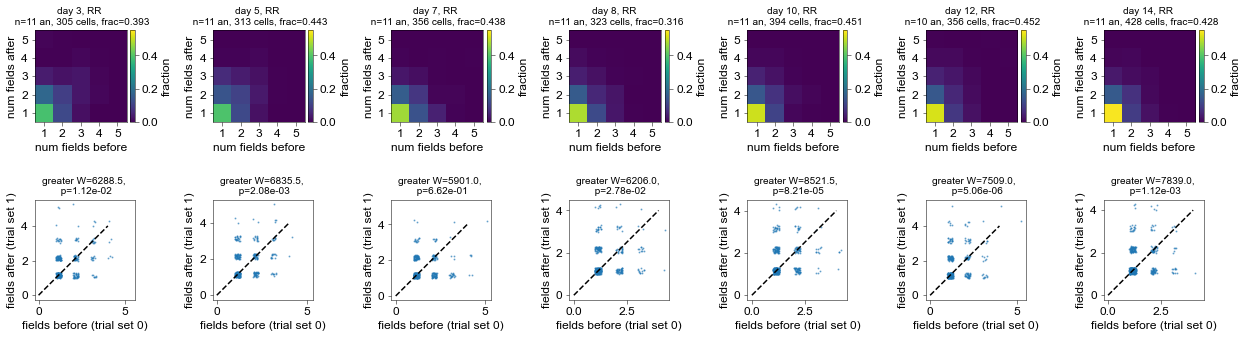

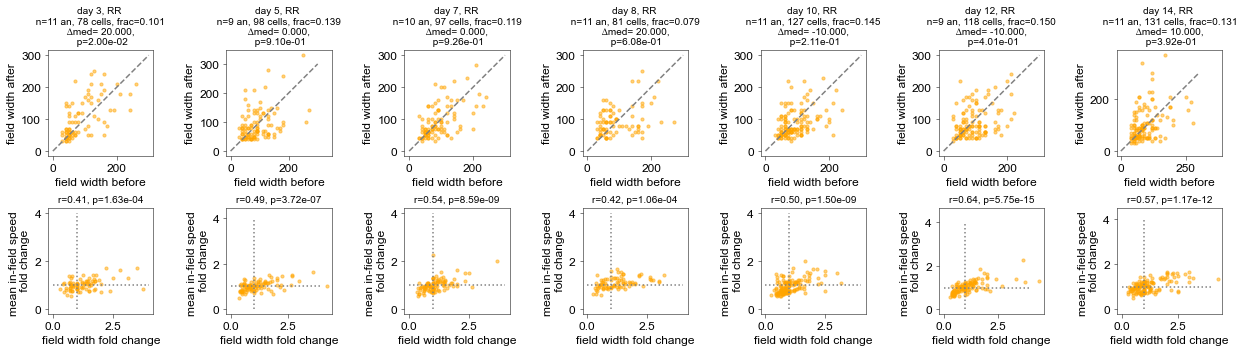

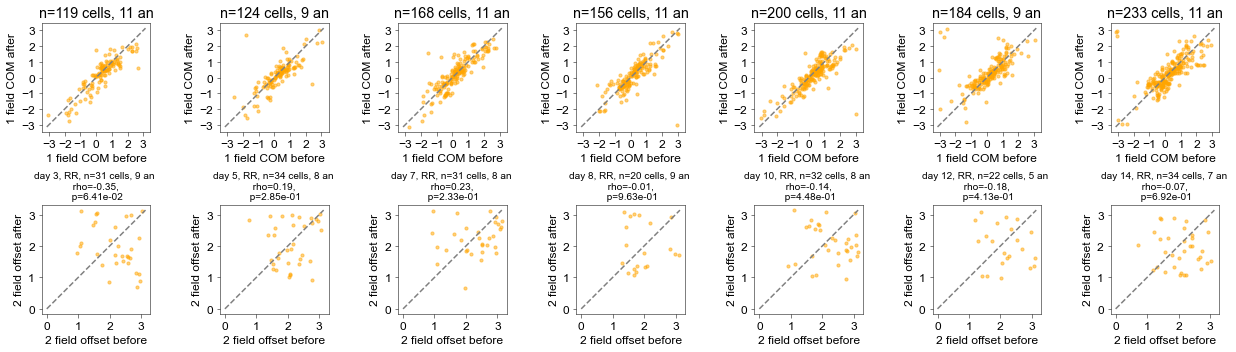

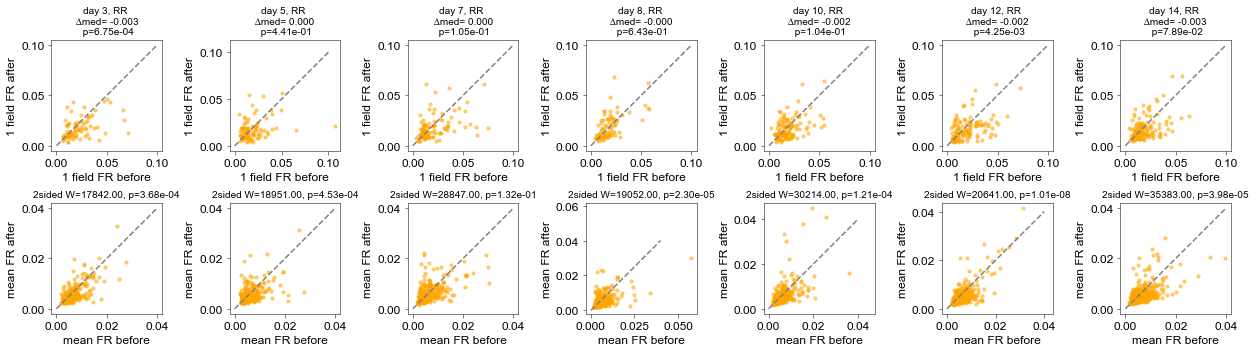

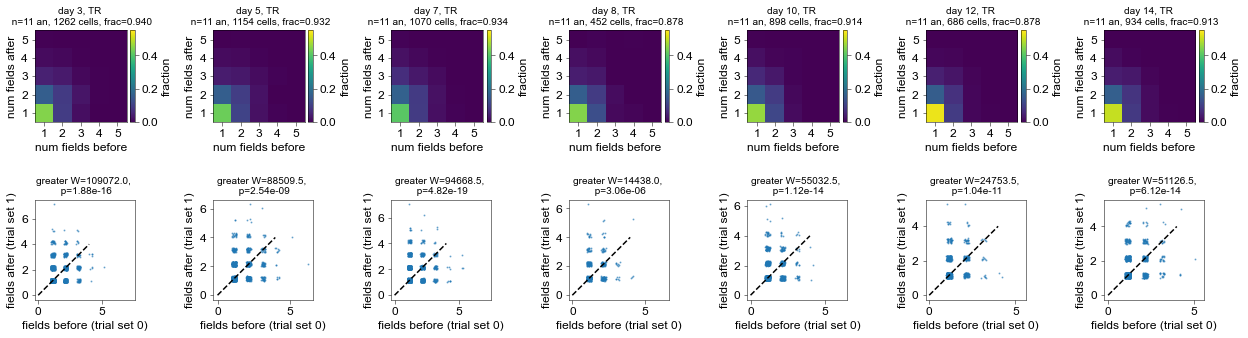

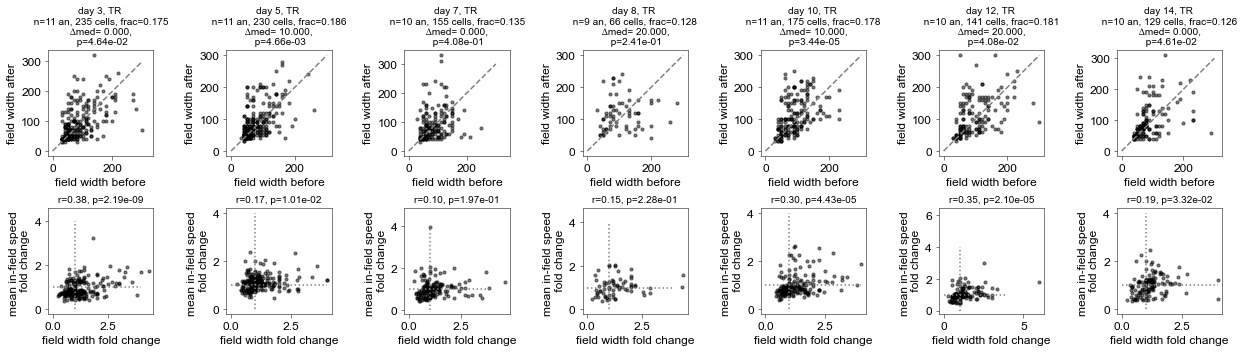

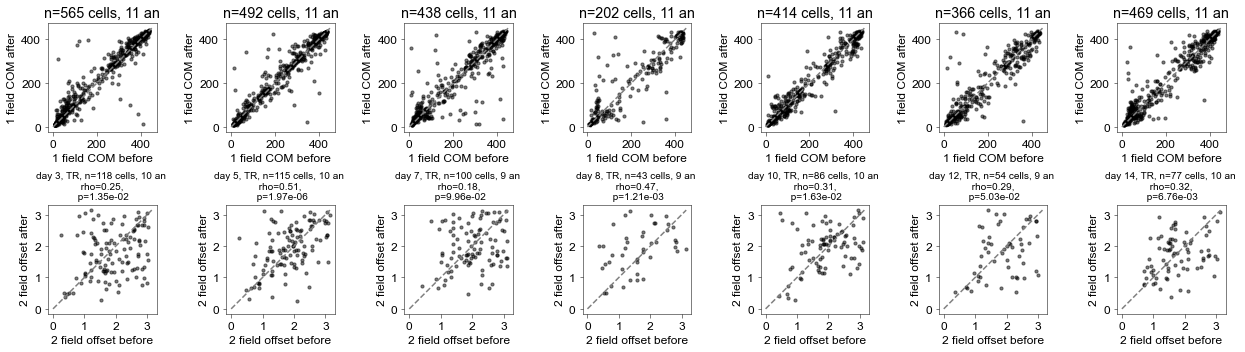

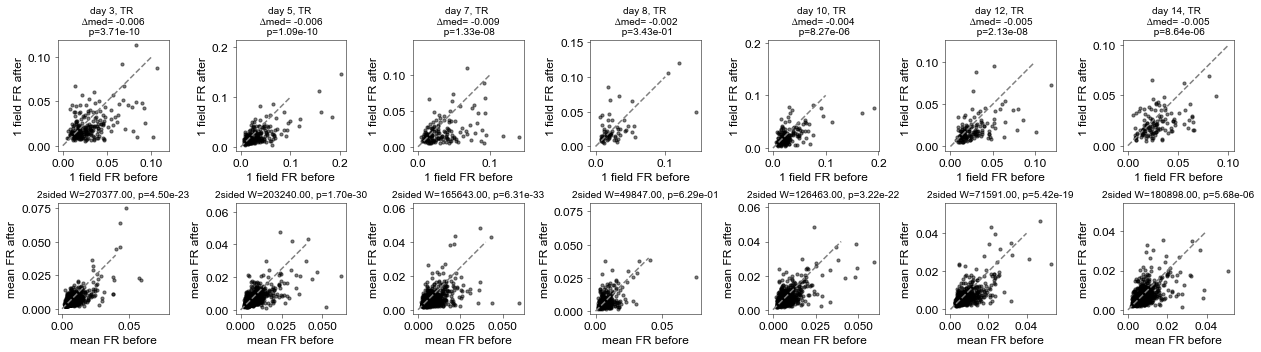

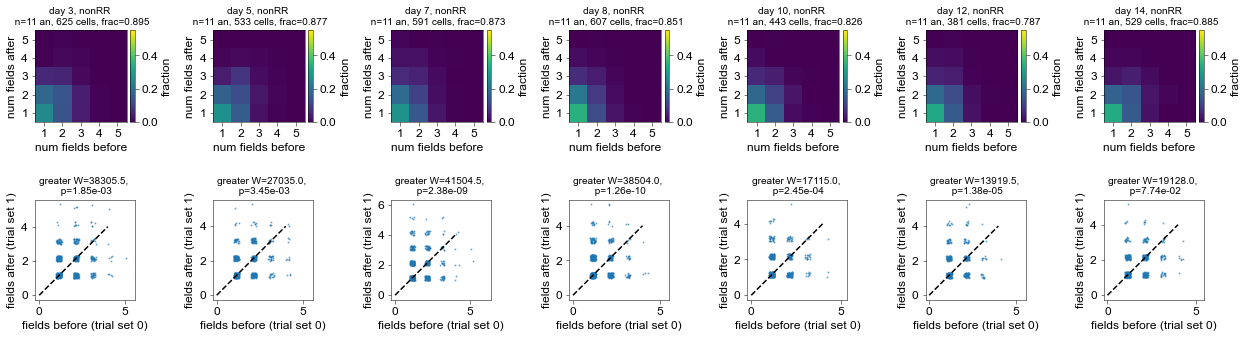

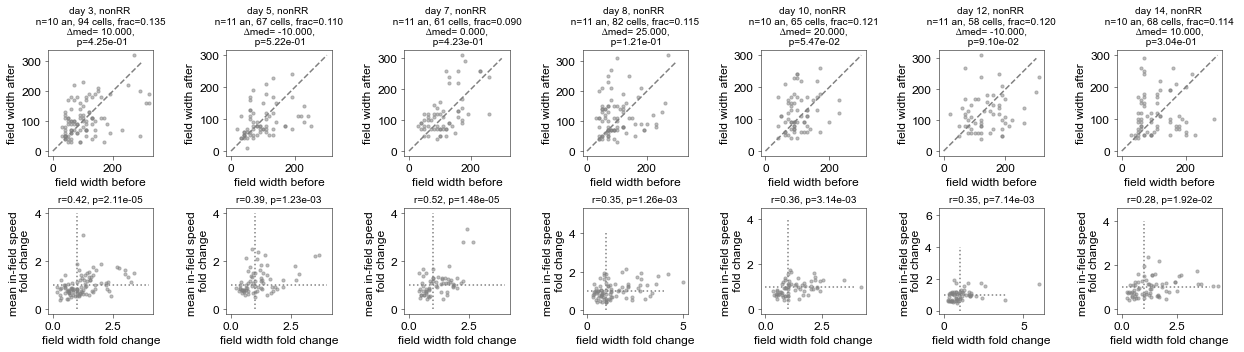

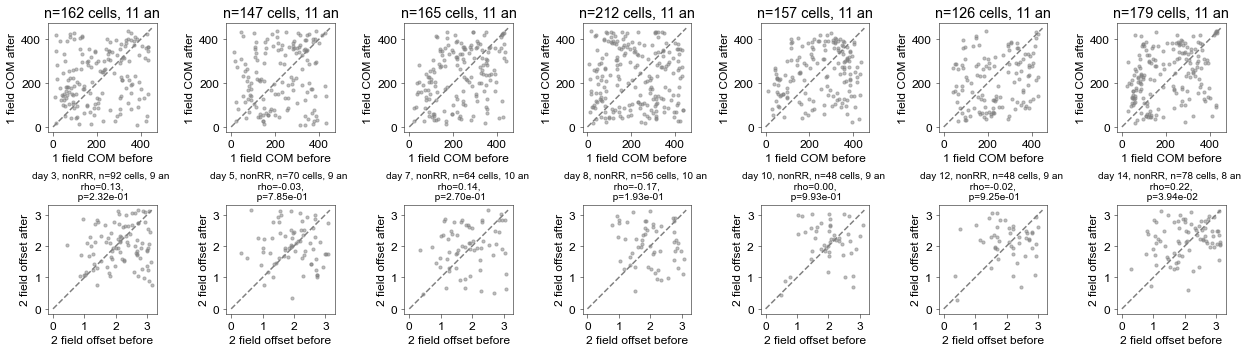

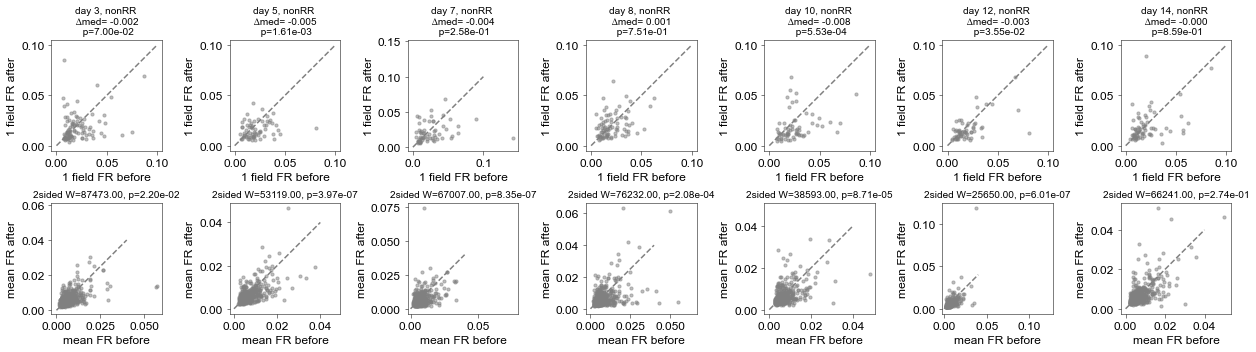

In [12]:
# 2d histogram of how many cells have how many fields ( and collect widths and COM)
# allows for max 4 fields and I never observe more than this for cells with sig fields
num_bins = np.arange(1, 7, 1)-0.5

exclude_edge_fields_throughout = False

ct_keys = ['RR', 'TR', 'nonRR', 'appear']
# need to include appear to get the formation laps even though other field properties will be skipped
ct_colors = ['orange', 'black', 'grey']

hist2d_per_day = dict([(ct, {}) for ct in ct_keys])
# n_w_sig_fields = {}
field_counts = dict([(ct, {}) for ct in ct_keys])
single_field_widths = dict([(ct, {}) for ct in ct_keys])
single_field_mean_speed = dict([(ct, {}) for ct in ct_keys])
single_field_COM = dict([(ct, {}) for ct in ct_keys])
two_field_COM = dict([(ct, {}) for ct in ct_keys])
multi_field_COM = dict([(ct, {}) for ct in ct_keys])
multi_field_formation_lap = dict([(ct, {}) for ct in ct_keys])
mean_FR = dict([(ct, {}) for ct in ct_keys])
single_field_FR = dict([(ct, {}) for ct in ct_keys])

single_field_diff_df = pd.DataFrame(columns=['day', 'ct', 'width', 'field_FR'])
all_field_diff_df = pd.DataFrame(
    columns=['day', 'ct', 'field_count_diff', 'mean_FR'])
corr_df = pd.DataFrame(
    columns=['day', 'ct', 'width_speed_r', 'width_speed_p', 'offset_r', 'offset_p'])

for ct_i, ct in enumerate(ct_keys):

    if ct != 'appear':  # don't plot, can't compare before vs. after if there was no field before
        fig, ax = plt.subplots(2, len(exp_days), figsize=[
                               2.5*len(exp_days), 5])
        fig_w, ax_w = plt.subplots(2, len(exp_days), figsize=[
                                   2.5*len(exp_days), 5])
        fig_com, ax_com = plt.subplots(2, len(exp_days), figsize=[
            2.5*len(exp_days), 5])
        fig_fr, ax_fr = plt.subplots(2, len(exp_days), figsize=[
            2.5*len(exp_days), 5])
        [ax_w[0, i].plot([0, 300], [0, 300], '--', color='grey')
         for i in range(ax_w.shape[1])]
        [ax_w[1, i].plot([0, 4], [1, 1], ':', color='grey')
         for i in range(ax_w.shape[1])]
        [ax_w[1, i].plot([1, 1], [0, 4], ':', color='grey')
         for i in range(ax_w.shape[1])]
        [ax_fr[0, i].plot([0, 0.1], [0, 0.1], '--', color='grey')
         for i in range(ax_fr.shape[1])]
        [ax_fr[1, i].plot([0, 0.04], [0, 0.04], '--', color='grey')
         for i in range(ax_fr.shape[1])]

        if ct == 'RR':
            [ax_com[0, i].plot([-np.pi, np.pi], [-np.pi, np.pi],
                               '--', color='grey') for i in range(ax_com.shape[1])]
        else:
            [ax_com[0, i].plot([0, 450], [0, 450], '--', color='grey')
             for i in range(ax_com.shape[1])]
        [ax_com[1, i].plot([0, np.pi], [0, np.pi], '--', color='grey')
         for i in range(ax_com.shape[1])]

    for d_i, day in enumerate(super_field_dict.keys()):
        hist2d_per_day[ct][day] = np.zeros((len(num_bins)-1, len(num_bins)-1))
        field_counts[ct][day] = {'set 0': [],
                                 'set 1': [],
                                 'diff': [],
                                 'n_cells': 0,
                                 'n_anim': 0,
                                 'fraction': 0,  # of total cells of this celltype
                                 }
        mean_FR[ct][day] = {'set 0': [],
                            'set 1': [], }
        multi_field_COM[ct][day] = {'set 0': {'primary': [],
                                              'secondary': []},
                                    'set 1': {'primary': [],
                                              'secondary': [],
                                              'main': []}
                                    }
        multi_field_formation_lap[ct][day] = {'main': []}

        single_field_widths[ct][day] = {'set 0': [],
                                        'set 1': [],
                                        'n_cells': 0,
                                        'n_anim': 0,
                                        'fraction': 0,  # of total cells of this celltype
                                        }
        single_field_mean_speed[ct][day] = {'set 0': [],
                                            'set 1': [],
                                            }
        single_field_COM[ct][day] = {'set 0': [],
                                     'set 1': [],
                                     'n_cells': 0,
                                     'n_anim': 0,
                                     }
        single_field_FR[ct][day] = {'set 0': [],
                                    'set 1': [],
                                    # same n as single field COM
                                    }
        two_field_COM[ct][day] = {'set 0': np.zeros((1, 2))*np.nan,
                                  'set 1': np.zeros((1, 2))*np.nan,
                                  'offset': {'set 0': np.zeros((1, 1))*np.nan,
                                             'set 1': np.zeros((1, 1))*np.nan},
                                  'n_cells': 0,
                                  'n_anim': 0,
                                  'fraction': 0,  # of total cells of this celltype
                                  }

        for an in include_ans:
            # Get original list of cell IDs
            orig_cells = np.array(
                list(super_field_dict[day][an]['field_dict']['set 0']['number'].keys()))
            orig_field_num_0 = np.array(
                list(super_field_dict[day][an]['field_dict']['set 0']['number'].values()))
            orig_field_num_1 = np.array(
                list(super_field_dict[day][an]['field_dict']['set 1']['number'].values()))

            # find cells of this cell type to include
            # for field width, firing rate in field - exclude cells with fields at the edges
            find_this_ct_w = (np.isin(orig_cells, super_field_dict[day][an]['nonedge_field_cells']) &
                              np.isin(orig_cells, np.where(
                                  super_field_dict[day][an][ct + '_masks'])[0])
                              )

            # for other calculations, require at least 1 field before/after, allow edges:
            if exclude_edge_fields_throughout:
                find_this_ct = (np.isin(orig_cells, super_field_dict[day][an]['nonedge_field_cells']) &
                                np.isin(orig_cells, np.where(
                                    super_field_dict[day][an][ct + '_masks'])[0])
                                )
            else:
                find_this_ct = (np.isin(orig_cells, super_field_dict[day][an]['sig_field_cells']) &
                                np.isin(orig_cells, np.where(
                                    super_field_dict[day][an][ct + '_masks'])[0])
                                )

                if ct == 'appear':
                    # for appear, obviously don't require a sig field before and after,
                    # because it doesn't have a sig field before by definition
                    sig_field_after = orig_cells[orig_field_num_1 > 0]
                    find_this_ct = (np.isin(orig_cells, sig_field_after) &
                                    np.isin(orig_cells, np.where(
                                        super_field_dict[day][an][ct + '_masks'])[0])
                                    )

            # skip everything but formation lap for appearing cells
            if ct != 'appear':

                # quantify width comparison, firing rate for cells with single field before and after
                find_single_field = ((orig_field_num_0 == 1) &
                                     (orig_field_num_1 == 1))

                single_field_widths[ct][day]['set 0'].append([
                    super_field_dict[day][an]['field_dict']['set 0']['widths'][cell][0]
                    for cell in orig_cells[(find_single_field & find_this_ct_w)]]
                )

                single_field_widths[ct][day]['set 1'].append([
                    super_field_dict[day][an]['field_dict']['set 1']['widths'][cell][0]
                    for cell in orig_cells[(find_single_field & find_this_ct_w)]]
                )

                single_field_mean_speed[ct][day]['set 0'].append([
                    super_field_dict[day][an]['field_dict']['set 0']['mean_speed_in_field'][cell][0]
                    for cell in orig_cells[(find_single_field & find_this_ct_w)]]
                )

                single_field_mean_speed[ct][day]['set 1'].append([
                    super_field_dict[day][an]['field_dict']['set 1']['mean_speed_in_field'][cell][0]
                    for cell in orig_cells[(find_single_field & find_this_ct_w)]]
                )

                single_field_FR[ct][day]['set 0'].append([
                    super_field_dict[day][an]['field_dict']['set 0']['mean_FR_in_field'][cell]
                    for cell in orig_cells[(find_single_field & find_this_ct_w)]]
                )

                single_field_FR[ct][day]['set 1'].append([
                    super_field_dict[day][an]['field_dict']['set 1']['mean_FR_in_field'][cell]
                    for cell in orig_cells[(find_single_field & find_this_ct_w)]]
                )

                single_field_widths[ct][day]['n_cells'] += len(
                    orig_cells[(find_single_field & find_this_ct_w)])

                # for other calculations, require at least 1 field before/after, allow edges:

                # find field numbers of the included cells
                sig_field_num_0 = orig_field_num_0[find_this_ct]
                sig_field_num_1 = orig_field_num_1[find_this_ct]

                field_counts[ct][day]['set 0'].append(list(sig_field_num_0))
                field_counts[ct][day]['set 1'].append(list(sig_field_num_1))

                mean_FR[ct][day]['set 0'].append([
                    super_field_dict[day][an]['field_dict']['set 0']['mean_FR'][cell]
                    for cell in orig_cells[find_this_ct]]
                )
                mean_FR[ct][day]['set 1'].append([
                    super_field_dict[day][an]['field_dict']['set 1']['mean_FR'][cell]
                    for cell in orig_cells[find_this_ct]]
                )

                # Find COM for cells with single fields
                # use circular COM if RR; linear if TR or nonRR
                if ct == 'RR':
                    use_COM = 'circ_COM_aligned'
                else:
                    use_COM = 'COM'

                single_field_COM[ct][day]['set 0'].append([
                    super_field_dict[day][an]['field_dict']['set 0'][use_COM][cell].squeeze(
                    )
                    for cell in orig_cells[(find_single_field & find_this_ct)]]
                )
                single_field_COM[ct][day]['set 1'].append([
                    super_field_dict[day][an]['field_dict']['set 1'][use_COM][cell].squeeze(
                    )
                    for cell in orig_cells[(find_single_field & find_this_ct)]]
                )

                # get field offset in circular coords for cells with exactly 2 fields before and after
                find_two_field = ((orig_field_num_0 == 2) &
                                  (orig_field_num_1 == 2))
                # make an array for this animal
                this_two_field_COM_0 = np.zeros(
                    (np.sum((find_two_field & find_this_ct)), 2))
                this_two_field_COM_1 = np.zeros(
                    (np.sum((find_two_field & find_this_ct)), 2))
                this_two_field_offset_0 = np.zeros(
                    (np.sum((find_two_field & find_this_ct)), 1))
                this_two_field_offset_1 = np.zeros(
                    (np.sum((find_two_field & find_this_ct)), 1))

                for i, cell in enumerate(orig_cells[(find_two_field & find_this_ct)]):
                    this_two_field_COM_0[i,
                                         :] = super_field_dict[day][an]['field_dict']['set 0']['circ_COM_aligned'][cell].T
                    this_two_field_COM_1[i,
                                         :] = super_field_dict[day][an]['field_dict']['set 1']['circ_COM_aligned'][cell].T
                    this_two_field_offset_0[i, :] = circ.phase_diff(
                        this_two_field_COM_0[i, 1], this_two_field_COM_0[i, 0])
                    this_two_field_offset_1[i, :] = circ.phase_diff(
                        this_two_field_COM_1[i, 1], this_two_field_COM_1[i, 0])

                two_field_COM[ct][day]['set 0'] = np.vstack(
                    [two_field_COM[ct][day]['set 0'], this_two_field_COM_0])
                two_field_COM[ct][day]['set 1'] = np.vstack(
                    [two_field_COM[ct][day]['set 1'], this_two_field_COM_1])
                two_field_COM[ct][day]['offset']['set 0'] = np.vstack([two_field_COM[ct][day]['offset']['set 0'],
                                                                       this_two_field_offset_0])
                two_field_COM[ct][day]['offset']['set 1'] = np.vstack([two_field_COM[ct][day]['offset']['set 1'],
                                                                       this_two_field_offset_1])

                # Get the 2d histogram in counts for each animal and add it to the total
                # Values in `x`
                # are histogrammed along the first dimension and values in `y` are
                # histogrammed along the second dimension.
                xedges, yedges, hist2d = spatial.smooth_hist_2d(sig_field_num_0, sig_field_num_1,
                                                                bins=num_bins,
                                                                smooth=False,
                                                                probability=False)

                hist2d_per_day[ct][day] += hist2d

                # Get n counts
                field_counts[ct][day]['n_cells'] += len(
                    orig_cells[find_this_ct])
                two_field_COM[ct][day]['n_cells'] += len(
                    orig_cells[(find_two_field & find_this_ct)])
                single_field_COM[ct][day]['n_cells'] += len(
                    orig_cells[(find_single_field & find_this_ct)])

                if hist2d.ravel().sum() > 0:
                    field_counts[ct][day]['n_anim'] += 1
                if len(orig_cells[(find_single_field & find_this_ct_w)]) > 0:
                    single_field_widths[ct][day]['n_anim'] += 1
                if len(orig_cells[(find_single_field & find_this_ct)]) > 0:
                    single_field_COM[ct][day]['n_anim'] += 1
                if len(orig_cells[(find_two_field & find_this_ct)]) > 0:
                    two_field_COM[ct][day]['n_anim'] += 1

            # identify primary/secondary fields, where primary or "main" field = 
            #     the field that is closest to to the peak spatial
            #     firing position of the cell used for categorization,
            #     and get the formation laps for those main fields
            for i, cell in enumerate(orig_cells[(find_this_ct)]):
                # find distributions of COM for primary and non-primary fields for RR cells:
                if ct != 'appear':
                    list_1 = super_field_dict[day][an]['field_dict']['set 0']['circ_COM_aligned'][cell]
                    list_2 = super_field_dict[day][an]['field_dict']['set 1']['circ_COM_aligned'][cell]

                    primary_0 = (np.argmin(np.abs(
                        super_field_dict[day][an]['field_dict']['set 0']['COM'][cell] -
                        multiDayData[day].peaks[an]['set 0'][cell]))
                    )
                    primary_1 = (np.argmin(np.abs(
                        super_field_dict[day][an]['field_dict']['set 1']['COM'][cell] -
                        multiDayData[day].peaks[an]['set 1'][cell]))
                    )
                    secondary_0 = np.where(super_field_dict[day][an]['field_dict']['set 0']['COM'][cell] !=
                                           super_field_dict[day][an]['field_dict']['set 0']['COM'][cell][primary_0])[0]
                    secondary_1 = np.where(super_field_dict[day][an]['field_dict']['set 1']['COM'][cell] !=
                                           super_field_dict[day][an]['field_dict']['set 1']['COM'][cell][primary_1])[0]

                    multi_field_COM[ct][day]['set 0']['primary'].append(
                        list_1[primary_0])
                    multi_field_COM[ct][day]['set 1']['primary'].append(
                        list_2[primary_1])
                    multi_field_COM[ct][day]['set 0']['secondary'].append(
                        list_1[secondary_0])
                    multi_field_COM[ct][day]['set 1']['secondary'].append(
                        list_2[secondary_1])

                # for formation lap, use the "main" field that correponds to the peak spatial firing of the cell in set 1
                _form_laps_per_field = super_field_dict[day][an]['field_dict']['set 1']['formation_lap'][cell]


                main_field = (np.argmin(np.abs(
                    super_field_dict[day][an]['field_dict']['set 1']['COM'][cell] -
                    multiDayData[day].peaks[an]['set 1'][cell]))
                )
                multi_field_COM[ct][day]['set 1']['main'].append(
                    super_field_dict[day][an]['field_dict']['set 1']['circ_COM_aligned'][cell][main_field]
                )
                multi_field_formation_lap[ct][day]['main'].append(
                    _form_laps_per_field[main_field]
                )

        if ct != 'appear':
            # normalize
            hist2d_per_day[ct][day] = hist2d_per_day[ct][day] / \
                np.sum(hist2d_per_day[ct][day].ravel())

            # convert everything to single array format
            field_counts[ct][day]['set 0'] = np.concatenate(
                field_counts[ct][day]['set 0'])
            field_counts[ct][day]['set 1'] = np.concatenate(
                field_counts[ct][day]['set 1'])
            single_field_widths[ct][day]['set 0'] = np.concatenate(
                single_field_widths[ct][day]['set 0'])
            single_field_widths[ct][day]['set 1'] = np.concatenate(
                single_field_widths[ct][day]['set 1'])
            single_field_mean_speed[ct][day]['set 0'] = np.concatenate(
                single_field_mean_speed[ct][day]['set 0'])
            single_field_mean_speed[ct][day]['set 1'] = np.concatenate(
                single_field_mean_speed[ct][day]['set 1'])
            single_field_COM[ct][day]['set 0'] = np.concatenate(
                single_field_COM[ct][day]['set 0'])
            single_field_COM[ct][day]['set 1'] = np.concatenate(
                single_field_COM[ct][day]['set 1'])
            single_field_FR[ct][day]['set 0'] = np.concatenate(
                single_field_FR[ct][day]['set 0'])
            single_field_FR[ct][day]['set 1'] = np.concatenate(
                single_field_FR[ct][day]['set 1'])
            mean_FR[ct][day]['set 0'] = np.concatenate(
                mean_FR[ct][day]['set 0'])
            mean_FR[ct][day]['set 1'] = np.concatenate(
                mean_FR[ct][day]['set 1'])
            # compare speed and width scales as a ratio (fold change)
            single_field_widths[ct][day]['width_diff'] = (
                single_field_widths[ct][day]['set 1'] - single_field_widths[ct][day]['set 0'])
            single_field_widths[ct][day]['width_ratio'] = (
                single_field_widths[ct][day]['set 1']/single_field_widths[ct][day]['set 0'])
            single_field_mean_speed[ct][day]['speed_ratio'] = (
                single_field_mean_speed[ct][day]['set 1']/single_field_mean_speed[ct][day]['set 0'])
            field_counts[ct][day]['diff'] = field_counts[ct][day]['set 1'] - \
                field_counts[ct][day]['set 0']

            if ct == 'RR':
                total_cells = np.sum(
                    [len(multiDayData[day].reward_rel_cell_ids[an]) for an in include_ans])
            else:
                total_cells = np.sum(
                    [np.sum(super_field_dict[day][an][ct + '_masks']) for an in include_ans])
            # print('day', day, ct, 'total cells', total_cells)
            field_counts[ct][day]['fraction'] = field_counts[ct][day]['n_cells']/total_cells
            single_field_widths[ct][day]['fraction'] = single_field_widths[ct][day]['n_cells']/total_cells
            two_field_COM[ct][day]['fraction'] = two_field_COM[ct][day]['n_cells']/total_cells
            # print(num_bins[np.argmax(hist2d_per_day[ct][day],axis=0)]+0.5)
            # print(num_bins[np.argmax(hist2d_per_day[ct][day],axis=1)]+0.5)

            # add things to single field dataframe
            n_entries = len(single_field_widths[ct][day]['width_diff'])
            day_arr = np.repeat(day, n_entries)
            ct_arr = np.repeat(ct, n_entries)
            df_this_day = pd.DataFrame({
                'day': day_arr,
                'ct': ct_arr,
                'width': single_field_widths[ct][day]['width_diff'],
                'field_FR': (
                    single_field_FR[ct][day]['set 1'] -
                    single_field_FR[ct][day]['set 0']
                ), }
            )
            single_field_diff_df = single_field_diff_df.append(df_this_day,
                                                               ignore_index=True)

            # add things to multifield dataframe
            n_entries = field_counts[ct][day]['n_cells']
            day_arr = np.repeat(day, n_entries)
            ct_arr = np.repeat(ct, n_entries)

            df_this_day = pd.DataFrame({
                'day': day_arr,
                'ct': ct_arr,
                'field_count_diff': field_counts[ct][day]['diff'].astype(float),
                'mean_FR': (
                    mean_FR[ct][day]['set 1'] -
                    mean_FR[ct][day]['set 0']
                ), }
            )
            all_field_diff_df = all_field_diff_df.append(df_this_day,
                                                         ignore_index=True)

            # Plot the 2d histograms of field counts
            h = ax[0, d_i].imshow(hist2d_per_day[ct][day].T, extent=(
                xedges[0], xedges[-1], yedges[-1], yedges[0]), cmap='viridis', vmin=0, vmax=0.55)
            ax[0, d_i].set_xticks((num_bins+0.5)[:-1])
            ax[0, d_i].set_yticks((num_bins+0.5)[:-1])
            ax[0, d_i].invert_yaxis()
            ax[0, d_i].axis('square')
            ax[0, d_i].set_xlabel('num fields before')
            ax[0, d_i].set_ylabel('num fields after')
            pt.colorbar(h, label="fraction")
            ax[0, d_i].set_title('day %d, %s \n n=%d an, %d cells, frac=%.3f' % (day, ct,
                                                                                 field_counts[ct][day]['n_anim'],
                                                                                 field_counts[ct][day]['n_cells'],
                                                                                 field_counts[ct][day]['fraction']),
                                 fontsize=10)

            # sanity check with the jittered scatter
            st = sp.stats.wilcoxon(
                field_counts[ct][day]['set 1'], field_counts[ct][day]['set 0'], alternative="greater")
            ax[1, d_i].scatter(field_counts[ct][day]['set 0']+np.random.rand(len(field_counts[ct][day]['set 0']))*0.3,
                               field_counts[ct][day]['set 1'] +
                               np.random.rand(
                                   len(field_counts[ct][day]['set 1']))*0.3,
                               s=1, alpha=0.5)

            ax[1, d_i].plot([0, 4], [0, 4], '--k')
            ax[1, d_i].set_xlabel('fields before (trial set 0)')
            ax[1, d_i].set_ylabel('fields after (trial set 1)')
            ax[1, d_i].set_title('greater W=%.1f, \n p=%.2e' %
                                 (st.statistic, st.pvalue), fontsize=10)
            ax[1, d_i].axis("square")

            # field widths
            width_st = sp.stats.wilcoxon(
                single_field_widths[ct][day]['set 1'], single_field_widths[ct][day]['set 0'])
            ax_w[0, d_i].scatter(single_field_widths[ct][day]['set 0'],
                                 single_field_widths[ct][day]['set 1'],
                                 color=ct_colors[ct_i],
                                 alpha=0.5,
                                 s=10)
            ax_w[0, d_i].axis('square')
            ax_w[0, d_i].set_xlabel('field width before')
            ax_w[0, d_i].set_ylabel('field width after')
            ax_w[0, d_i].set_title(
                'day %d, %s \n n=%d an, %d cells, frac=%.3f \n ∆med= %.3f, \n p=%.2e' % (day,
                                                                                         ct,
                                                                                         single_field_widths[
                                                                                             ct][day]['n_anim'],
                                                                                         single_field_widths[
                                                                                             ct][day]['n_cells'],
                                                                                         single_field_widths[ct][
                                                                                             day]['fraction'],
                                                                                         (np.nanmedian(single_field_widths[ct][day]['set 1']) -
                                                                                          np.nanmedian(
                                                                                              single_field_widths[ct][day]['set 0'])
                                                                                          ),
                                                                                         width_st.pvalue),
                fontsize=10)

            # correlation of field width with running speed
            width_speed_corr = sp.stats.pearsonr(single_field_widths[ct][day]['width_ratio'],
                                                 single_field_mean_speed[ct][day]['speed_ratio']
                                                 )

            ax_w[1, d_i].scatter(single_field_widths[ct][day]['width_ratio'],
                                 single_field_mean_speed[ct][day]['speed_ratio'],
                                 color=ct_colors[ct_i],
                                 alpha=0.5,
                                 s=10)
            ax_w[1, d_i].axis('square')
            ax_w[1, d_i].set_xlabel('field width fold change')
            ax_w[1, d_i].set_ylabel('mean in-field speed \n fold change')

            ax_w[1, d_i].set_title('r=%.2f, p=%.2e' % (
                width_speed_corr[0],
                width_speed_corr[1]),
                fontsize=10)

            # field COM
            ax_com[0, d_i].scatter(single_field_COM[ct][day]['set 0'],
                                   single_field_COM[ct][day]['set 1'],
                                   color=ct_colors[ct_i],
                                   alpha=0.5,
                                   s=10)
            if ct == 'RR':
                ax_com[0, d_i].set_xticks([-3, -2, -1, 0, 1, 2, 3])
                ax_com[0, d_i].set_yticks([-3, -2, -1, 0, 1, 2, 3])
            ax_com[0, d_i].axis('square')
            ax_com[0, d_i].set_xlabel('1 field COM before')
            ax_com[0, d_i].set_ylabel('1 field COM after')
            ax_com[0, d_i].set_title('n=%d cells, %d an' % (single_field_COM[ct][day]['n_cells'],
                                                            single_field_COM[ct][day]['n_anim']
                                                            ))

            # circular correlation of offsets
            cc_rho, cc_pval, _ = ppcore.corr_cc(
                two_field_COM[ct][day]['offset']['set 0'][~np.isnan(
                    two_field_COM[ct][day]['offset']['set 0'])],
                two_field_COM[ct][day]['offset']['set 1'][~np.isnan(
                    two_field_COM[ct][day]['offset']['set 1'])]
            )
            ax_com[1, d_i].scatter(two_field_COM[ct][day]['offset']['set 0'],
                                   two_field_COM[ct][day]['offset']['set 1'],
                                   color=ct_colors[ct_i],
                                   alpha=0.5,
                                   s=10)

            ax_com[1, d_i].axis('square')
            ax_com[1, d_i].set_xticks([0, 1, 2, 3])
            ax_com[1, d_i].set_yticks([0, 1, 2, 3])
            ax_com[1, d_i].set_xlabel('2 field offset before')
            ax_com[1, d_i].set_ylabel('2 field offset after')
            ax_com[1, d_i].set_title('day %d, %s, n=%d cells, %d an \n rho=%.2f, \n p=%.2e' % (day, ct,
                                                                                               two_field_COM[ct][day]['n_cells'],
                                                                                               two_field_COM[ct][day]['n_anim'],
                                                                                               cc_rho,
                                                                                               cc_pval),
                                     fontsize=10)

            # put correlation stats in dataframe
            this_corr_df = pd.DataFrame([{'day': day,
                                          'ct': ct,
                                          'width_speed_r': width_speed_corr[0],
                                          'width_speed_p': width_speed_corr[1],
                                          'offset_r': cc_rho,
                                          'offset_p': cc_pval,
                                          }])

            corr_df = corr_df.append(this_corr_df, ignore_index=False)

            # in-field FR
            fr_st = sp.stats.wilcoxon(
                single_field_FR[ct][day]['set 1'], single_field_FR[ct][day]['set 0'])
            ax_fr[0, d_i].scatter(single_field_FR[ct][day]['set 0'],
                                  single_field_FR[ct][day]['set 1'],
                                  color=ct_colors[ct_i],
                                  alpha=0.5,
                                  s=10)
            ax_fr[0, d_i].axis('square')
            ax_fr[0, d_i].set_xlabel('1 field FR before')
            ax_fr[0, d_i].set_ylabel('1 field FR after')
            ax_fr[0, d_i].set_title('day %d, %s \n ∆med= %.3f \n p=%.2e' % (day, ct,
                                                                            (np.nanmedian(single_field_FR[ct][day]['set 1']) -
                                                                             np.nanmedian(single_field_FR[ct][day]['set 0'])),
                                                                            fr_st.pvalue),
                                    fontsize=10)

            # mean FR (across the whole environment)
            mean_fr_st = sp.stats.wilcoxon(
                mean_FR[ct][day]['set 1'], mean_FR[ct][day]['set 0'])
            ax_fr[1, d_i].scatter(mean_FR[ct][day]['set 0'],
                                  mean_FR[ct][day]['set 1'],
                                  color=ct_colors[ct_i],
                                  alpha=0.5,
                                  s=10)
            ax_fr[1, d_i].axis('square')
            ax_fr[1, d_i].set_xlabel('mean FR before')
            ax_fr[1, d_i].set_ylabel('mean FR after')
            ax_fr[1, d_i].set_title('2sided W=%.2f, p=%.2e' % (mean_fr_st.statistic,
                                                               mean_fr_st.pvalue),
                                    fontsize=10)

    save_figures = False
    if ct != 'appear':
        save_figures = False
        if save_figures:
            if exclude_edge_fields_throughout:
                edge_tag = 'excEdges'
            else:
                edge_tag = 'incEdges'
            pt.savefig(fig, fig_dir, "%s_days%s_%s_2dhist_num_fields_before_vs_after_nstd%d_ntrials%d_%s" % (
                ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), ct, n_std, n_trials_thr, edge_tag), extension='.pdf'
            )
            pt.savefig(fig_w, fig_dir, "%s_days%s_%s_scatter_fields_widths_before_vs_after_nstd%d_ntrials%d_%s" % (
                ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), ct, n_std, n_trials_thr, edge_tag), extension='.svg'
            )
            pt.savefig(fig_com, fig_dir, "%s_days%s_%s_scatter_field_COMs_before_vs_after_nstd%d_ntrials%d_%s" % (
                ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), ct, n_std, n_trials_thr, edge_tag), extension='.svg'
            )
            pt.savefig(fig_fr, fig_dir, "%s_days%s_%s_scatter_field_FR_before_vs_after_nstd%d_ntrials%d_%s" % (
                ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), ct, n_std, n_trials_thr, edge_tag), extension='.svg'
            )

In [12]:
single_field_diff_df

,day,ct,width,field_FR
0,3,RR,50.0,0.000187
1,3,RR,100.0,-0.005664
2,3,RR,60.0,0.004641
3,3,RR,-20.0,-0.037004
4,3,RR,10.0,-0.019384
...,...,...,...,...
2351,14,nonRR,20.0,-0.004846
2352,14,nonRR,-20.0,0.001160
2353,14,nonRR,-40.0,-0.008662
2354,14,nonRR,-180.0,0.005879


In [13]:
# median significant activity change (based on p-values displayed above)
print('TR', single_field_diff_df.loc[
    (single_field_diff_df['ct']=='TR') & single_field_diff_df['day'].isin([3,5,7,10,12,14])]['field_FR'].median())
print('RR', single_field_diff_df.loc[
    (single_field_diff_df['ct']=='RR') & single_field_diff_df['day'].isin([3,12])]['field_FR'].median())
print('nonRR', single_field_diff_df.loc[
    (single_field_diff_df['ct']=='nonRR') & single_field_diff_df['day'].isin([5,10])]['field_FR'].median())

TR -0.005152256637886437
RR -0.0029723960160487
nonRR -0.005603103251448621


In [14]:
print('TR', single_field_diff_df.loc[
    (single_field_diff_df['ct']=='TR') & single_field_diff_df['day'].isin([5,10])]['width'].median())

TR 10.0


In [15]:
import pingouin

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


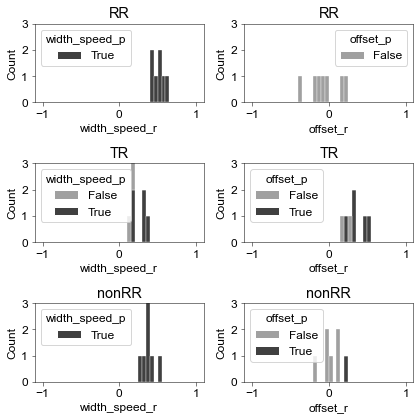

In [16]:
## Plot quantifications

pt.set_fig_params(fontsize=12)
        
fig_hist, ax_hist = plt.subplots(3,2, figsize=[6,6])
for ct_i,ct in enumerate(['RR','TR','nonRR']):
    sns.histplot(data=corr_df[corr_df['ct']==ct], ax=ax_hist[ct_i,0], stat="count", multiple="stack",
                 x="width_speed_r", kde=False, binwidth = 0.05, binrange = (-1,1),
                 palette={True: 'black', False: 'grey'}, hue=corr_df['width_speed_p'][corr_df['ct']==ct]<0.05,
                 element="bars", legend=True)
    ax_hist[ct_i,0].set_title(ct)
    ax_hist[ct_i,0].set_ylim([0,3])
    sns.histplot(data=corr_df[corr_df['ct']==ct], ax=ax_hist[ct_i,1], stat="count", multiple="stack",
                 x="offset_r", kde=False, binwidth = 0.05, binrange = (-1,1),
                 palette={True: 'black', False: 'grey'}, hue=corr_df['offset_p'][corr_df['ct']==ct]<0.05,
                 element="bars", legend=True)
    ax_hist[ct_i,1].set_title(ct)
    ax_hist[ct_i,1].set_ylim([0,3])

save_figures = False
if save_figures:
    pt.savefig(fig_hist, fig_dir, "%s_days%s_RR-TR-nonRR_hist_width-speed-corr_offset-corr_nstd%d_ntrials%d_%s" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), n_std, n_trials_thr, edge_tag), extension='.svg'
    )

In [43]:
# df_2dhist= pd.DataFrame()

# for day in [3,8,14]:
#     for ct in ct_keys:
#         np.savetxt(os.path.join(path_dict['preprocessed_root'],
#                              'source_data',
#                                 f"{ct}_day{day}_fieldCountHist.csv"), 
#                    hist2d_per_day[ct][day], delimiter=",")


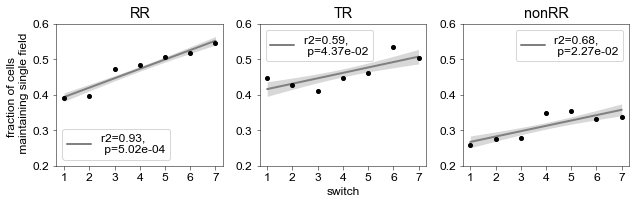

In [17]:
# linear regression on single field fraction over days
single_field_fraction = {}
switch_num = np.arange(len(exp_days))+1
fig, ax = plt.subplots(1,3, figsize=(9,3))

df_single_frac = pd.DataFrame({'switch': np.tile(np.arange(len(exp_days))+1, 3),
                               'ct': np.repeat(['RR','TR','nonRR'], 7),
                               'frac_cells_w_single_field': np.zeros((len(exp_days)*3),)*np.nan
                              })

for ct_i, ct in enumerate(['RR','TR','nonRR']):
    single_field_fraction[ct] = [hist2d_per_day[ct][d][0,0] for d in exp_days]
    df_single_frac.loc[df_single_frac['ct']==ct, 'frac_cells_w_single_field'] = np.array(single_field_fraction[ct])
    slope, intercept, line, reg_params = regression.linear_reg(switch_num,
                                                       np.array(single_field_fraction[ct]))
    h = pt.plot_mean_sem(ax[ct_i],line['y'],line['std'],xvalues=line['x'],
                     color='grey',
            label=('r2=%.2f, \n p=%.2e' % (reg_params['r2'],
                                        reg_params['p'])))
    
    ax[ct_i].plot(switch_num, single_field_fraction[ct], 'k.', markersize=8)
    ax[ct_i].legend()
    ax[ct_i].set_title(ct)
    

[ax[i].set_ylim([0.2,0.6]) for i in range(len(ax))];
[ax[i].set_xticks(np.arange(len(exp_days))+1) for i in range(len(ax))];
ax[0].set_ylabel('fraction of cells \n maintaining single field')
ax[1].set_xlabel('switch')
save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_days%s_%s_frac_single_field_before_and_after_LinReg_nstd%d_ntrials%d_%s" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), ct, n_std, n_trials_thr, edge_tag), extension='.svg'
    )

In [62]:
# ut.write_source_csv(df_single_frac, "Ext3d")

writing /data/2P/source_data/FigExt3d.csv


### Plot some examples place fields

/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday3_speed2_perms100_maximin_events.pickle


/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


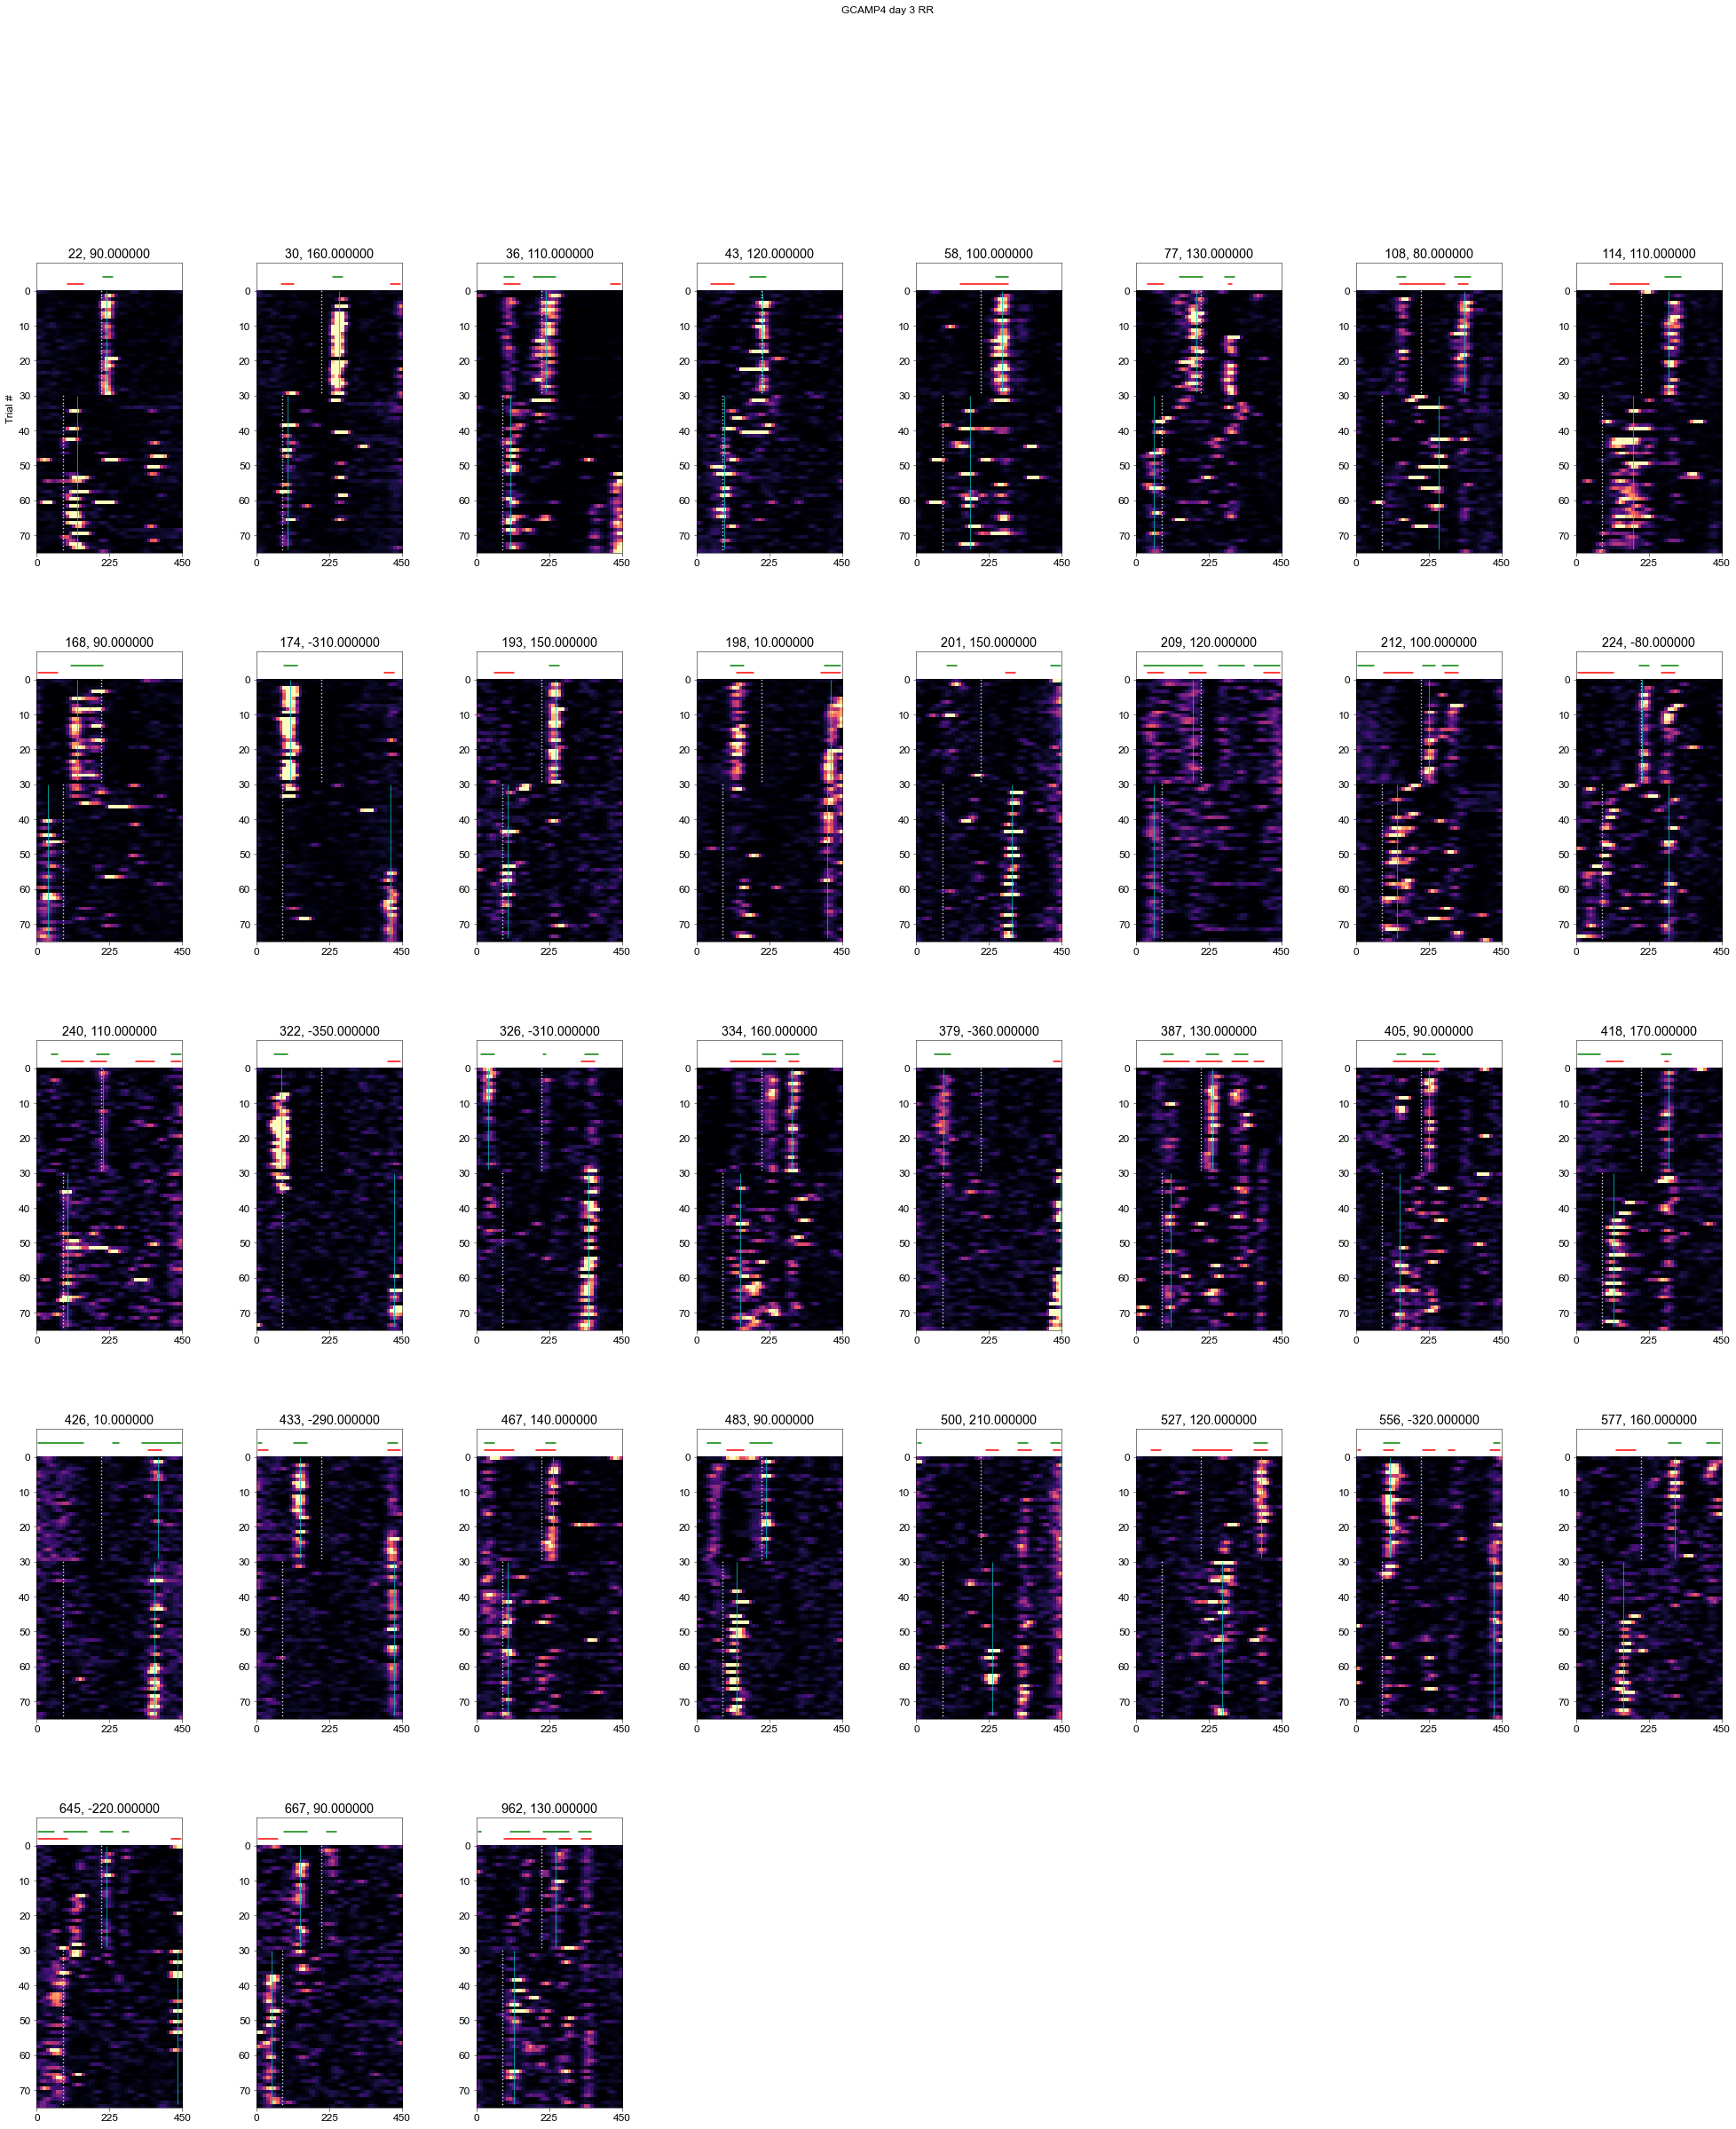

In [18]:
# plot some examples place fields
example_ans = ['GCAMP4'] 
example_days = [3] #,5,7,10,12,14]
example_cts = ['RR'] # cell type to plot


for d_i, day in enumerate(example_days):
    use_anim_list = dd.define_anim_list(experiment,exp_day=day, year='combined')
    if np.any(np.isin(example_ans, use_anim_list)):
        multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, use_anim_list,
                                               params={'speed': '2',
                                                       'nperms': 100,
                                                       'baseline_method': 'maximin',
                                                       'ts_key': 'events'
                                                       }
                                               )
    else:
        continue
    for ct_i, ct in enumerate(example_cts): #ct_keys):
        for an in example_ans:

            if an in multi_anim_sess.keys():
                orig_cells = np.array(list(super_field_dict[day][an]['field_dict']['set 0']['number'].keys()))
                orig_field_num_0 = np.array(list(super_field_dict[day][an]['field_dict']['set 0']['number'].values()))
                orig_field_num_1 = np.array(list(super_field_dict[day][an]['field_dict']['set 1']['number'].values()))
                has_multiple_fields = ((orig_field_num_0 > 1) | (orig_field_num_1 > 1))
                has_two_fields = ((orig_field_num_0 == 2) & (orig_field_num_1 == 2))
                has_single_field = ((orig_field_num_0 == 1) & (orig_field_num_1 == 1))
                find_this_ct = (np.isin(orig_cells, super_field_dict[day][an]['sig_field_cells']) &
                                                        np.isin(orig_cells, np.where(super_field_dict[day][an][ct + '_masks'])[0])
                                   )
                # find_this_ct = np.isin(orig_cells, np.where(super_field_dict[day][an][ct + '_masks'])[0])

                use_field_dict = super_field_dict[day][an]['field_dict']
                use_cells = orig_cells[(find_this_ct)] # & has_two_fields)]
                # use_cells = orig_cells[(find_this_ct & has_single_field)]

                # use_cells = orig_cells[np.isin(orig_cells, np.where(super_field_dict[day][an][ct + '_masks'])[0])]

                if len(use_cells)>0:
                    fig = placeCellPlot.plot_all_single_cells(multi_anim_sess[an]['sess'],
                                                  use_cells,
                                                  ts_key='events',
                                                  normalization_method='mean',
                                                  max_cells=500,
                                                  sigma=1,
                                                  plot_reward_zone=True,
                                                  circ_shift=False,
                                                  use_speed_thr=True,
                                                  plot_peaks=True,
                                                  field_pos=use_field_dict)  # ['set 1']['pos']) # multiDayData[day].field_dict[an]['set 1']['field pos'])

                    fig.suptitle("%s day %d %s" % (an, day, ct))
                    save_figures=False
                    if save_figures:
                        use_field_thr = ("%.1f" % field_thr)
                        pt.savefig(fig, fig_dir, "%s_day%d_%s_placePlot-w2SigKeepFields_%s_%dtrials_%dstd" % (
                            an, day, ct, use_field_thr, n_trials_thr, n_std), extension='.pdf'
                        )

In [19]:
day=3
an='GCAMP4'
cell=212
f_i=0
super_field_dict[day][an]['field_dict']['set 1']['formation_lap'][cell][f_i]

30.0

In [20]:
# COM of the example cell in Ext. Fig. 3l
super_field_dict[3]['GCAMP14']['field_dict']['set 1']['COM'][590], \
super_field_dict[3]['GCAMP14']['field_dict']['set 1']['field_coms_per_trial'][590][0][int(super_field_dict[3]['GCAMP14']['field_dict']['set 1']['formation_lap'][590].squeeze()-30)], \
int(super_field_dict[3]['GCAMP14']['field_dict']['set 1']['formation_lap'][590].squeeze()-30)

(array([[252.54956155]]), 266.02630420173546, 2)

# Field shifting
### Get field shift since formation lap

To do: consolidate this into the main function 'find_sig_active_fields'

In [21]:
# data frame for post-switch dynamics
cols = ['mouse',
        'day',
        'switch',
        'switch_dir',
        'cell',
        'ct',
        'field_id',
        'rel_COM',
        'COM',
        'formation_lap',
        'is_main_field',
        'shift',

        ]

# Dataframe to store shifts
shift_df = pd.DataFrame(columns=cols)
ct_keys = ['RR', 'TR', 'nonRR', 'appear']

for d_i, day in enumerate(exp_days):

    for ct in ct_keys:
        for an in include_ans:

            orig_cells = np.array(
                list(super_field_dict[day][an]['field_dict']['set 1']['number'].keys()))
         
            ## Find cells of this type that have significantly active fields
            find_this_ct = (np.isin(orig_cells, super_field_dict[day][an]['sig_field_cells']) &
                            np.isin(orig_cells, np.where(
                                super_field_dict[day][an][ct + '_masks'])[0])
                            )
          
            use_cells = orig_cells[(find_this_ct)]

            trials_from_switch = (np.where(multiDayData[day].trial_dict[an]['trial_set1'])[0] -
                                  np.where(multiDayData[day].trial_dict[an]['trial_set1'])[0][0])

            super_field_dict[day][an].update({'set1_dynamics': {
                                                                'formation_shift': dict([(c, {}) for c in use_cells]),
                                                                'main_field_id': dict([(c, {}) for c in use_cells])}
                                              })
            if multiDayData[day].rzone_pos[an]['set 1'][0] > multiDayData[day].rzone_pos[an]['set 0'][0]:
                switch_dir = 'forward'
            elif multiDayData[day].rzone_pos[an]['set 1'][0] < multiDayData[day].rzone_pos[an]['set 0'][0]:
                switch_dir = 'backward'
            else:
                switch_dir = 'none'

            if len(use_cells) > 0:

                for i, cell in enumerate(use_cells):

                    n_fields = super_field_dict[day][an]['field_dict']['set 1']['number'][cell]
                    super_field_dict[day][an]['set1_dynamics']['formation_shift'][cell] = np.zeros(
                        (n_fields,))*np.nan

                    for s in ['0', '1']:
                        trial_list = np.where(
                            multiDayData[day].trial_dict[an]['trial_set'+s])[0]

                        main_field = (np.argmin(np.abs(
                            super_field_dict[day][an]['field_dict']['set '+s]['COM'][cell] -
                            multiDayData[day].peaks[an]['set '+s][cell]))
                        )
                        
                        # iterate through individual fields
                        for f_i in super_field_dict[day][an]['field_dict']['set '+s]['field_coms_per_trial'][cell].keys():

                            # plot formation lap
                            if s == '1':
                                super_field_dict[day][an]['set1_dynamics']['main_field_id'][cell] = main_field
                                formation_lap = super_field_dict[day][an]['field_dict']['set 1']['formation_lap'][cell][f_i]

                                if ~np.isnan(formation_lap):
                                    formation_lap_idx = ut.lookup_ind(
                                        int(formation_lap), trial_list)

                                    formation_com = super_field_dict[day][an]['field_dict']['set 1'][
                                        'field_coms_per_trial'][cell][f_i][formation_lap_idx]

                                    # THIS COULD DEF HAPPEN IN THE FUNCTION
                                    # com of mean field at the last 30 trials of the session minus the com of the formation lap
                                    super_field_dict[day][an]['set1_dynamics']['formation_shift'][cell][f_i] = super_field_dict[day][an][
                                        'field_dict']['set 1']['COM'][cell][f_i] - formation_com

                                    if (np.isnan(super_field_dict[day][an][
                                            'field_dict']['set 1']['COM'][cell][f_i]) or np.isnan(formation_com)):
                                        raise NotImplementedError(
                                            'nan formation')

                                    if f_i == main_field:
                                        main_field_formation_lap = np.copy(
                                            formation_lap)
                                        main_field_formation_lap_idx = np.copy(
                                            formation_lap_idx)
                                        is_main_field = True
                                    else:
                                        is_main_field = False

                                     # add to dataframe
                                    shift_df = shift_df.append(pd.DataFrame({'mouse': an,
                                                                             'day': day,
                                                                             'switch': float(d_i+1),
                                                                             'switch_dir': switch_dir,
                                                                             'cell': cell,
                                                                             'ct': ct,
                                                                             'field_id': f_i,
                                                                             'rel_COM': super_field_dict[day][an]['field_dict']['set 1'][
                                                                                 'circ_COM_aligned'][cell][f_i],
                                                                             'COM': super_field_dict[day][an]['field_dict']['set 1']['COM'][cell][f_i],
                                                                             'formation_lap': formation_lap,
                                                                             'is_main_field': is_main_field,
                                                                             'shift': super_field_dict[day][an]['set1_dynamics']['formation_shift'][cell][f_i],
                                                                             }), ignore_index=True
                                                               )



### Shifting plots

RR n= 2368
TR n= 6255
nonRR n= 3445
appear n= 2386


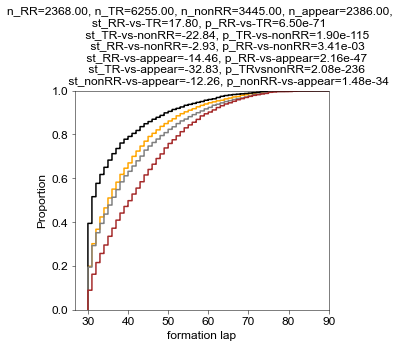

In [22]:
# CDF of formation laps (Ext. Fig. 3m)

fig_cdf, ax_cdf = plt.subplots(figsize=[4.5, 5])
# fig2, ax2 = plt.subplots(figsize=[4.5, 4])

primary_df = shift_df[shift_df['is_main_field']]

for ct_i, ct in enumerate(ct_keys):
    if ct == "RR":
        vcolor = "orange"
    elif ct == "TR":
        vcolor = "black"
    elif ct == "nonRR":
        vcolor = "grey"
    elif ct == "appear":
        vcolor = "brown"

    this_form_lap = primary_df.loc[(primary_df['ct'] == ct),
                                 'formation_lap']
    nanmask = ~np.isnan(this_form_lap)

    print(ct, 'n=', len(this_form_lap))
    sns.ecdfplot(
        data=this_form_lap,
        stat="proportion",
        legend=True,
        ax=ax_cdf,
        color=vcolor,
        label=ct,
    )

    # ranksums between populations

n_RR = len(primary_df.loc[(primary_df['ct'] == 'RR'),
                                 'formation_lap'].dropna())
n_TR = len(primary_df.loc[(primary_df['ct'] == 'TR'),
                                 'formation_lap'].dropna())
n_nonRR = len(primary_df.loc[(primary_df['ct'] == 'nonRR'),
                                 'formation_lap'].dropna())
n_appear = len(primary_df.loc[(primary_df['ct'] == 'appear'),
                                 'formation_lap'].dropna())

st_RRTR, p_RRTR = sp.stats.ranksums(
primary_df.loc[(primary_df['ct'] == 'RR'), 'formation_lap'],
primary_df.loc[(primary_df['ct'] == 'TR'), 'formation_lap'],

)
st_TRnonRR, p_TRnonRR = sp.stats.ranksums(
primary_df.loc[(primary_df['ct'] == 'TR'), 'formation_lap'],
primary_df.loc[(primary_df['ct'] == 'nonRR'), 'formation_lap'],
)
st_RRnonRR, p_RRnonRR = sp.stats.ranksums(
primary_df.loc[(primary_df['ct'] == 'RR'), 'formation_lap'],
primary_df.loc[(primary_df['ct'] == 'nonRR'), 'formation_lap'],
)
st_RRappear, p_RRappear = sp.stats.ranksums(
primary_df.loc[(primary_df['ct'] == 'RR'), 'formation_lap'],
primary_df.loc[(primary_df['ct'] == 'appear'), 'formation_lap'],
)
st_TRappear, p_TRappear = sp.stats.ranksums(
primary_df.loc[(primary_df['ct'] == 'TR'), 'formation_lap'],
primary_df.loc[(primary_df['ct'] == 'appear'), 'formation_lap'],
)
st_nonRRappear, p_nonRRappear = sp.stats.ranksums(
primary_df.loc[(primary_df['ct'] == 'nonRR'), 'formation_lap'],
primary_df.loc[(primary_df['ct'] == 'appear'), 'formation_lap'],
)

ax_cdf.set_xlabel("formation lap")

ax_cdf.set_title("n_RR=%.2f, n_TR=%.2f, n_nonRR=%.2f, n_appear=%.2f, \n \
    st_RR-vs-TR=%.2f, p_RR-vs-TR=%.2e \n \
                st_TR-vs-nonRR=%.2f, p_TR-vs-nonRR=%.2e  \n \
                st_RR-vs-nonRR=%.2f, p_RR-vs-nonRR=%.2e  \n \
                st_RR-vs-appear=%.2f, p_RR-vs-appear=%.2e  \n \
                st_TR-vs-appear=%.2f, p_TRvsnonRR=%.2e  \n \
                st_nonRR-vs-appear=%.2f, p_nonRR-vs-appear=%.2e "
    % (n_RR, n_TR, n_nonRR, n_appear,
        st_RRTR,
        p_RRTR,
        st_TRnonRR,
        p_TRnonRR,
        st_RRnonRR,
        p_RRnonRR,
        st_RRappear,
        p_RRappear,
        st_TRappear,
        p_TRappear,
        st_nonRRappear,
        p_nonRRappear,
    ),
    fontsize = 12,
);

ax_cdf.set_xticks(np.arange(30,100,10))
ax_cdf.set_xlim([ax_cdf.get_xlim()[0], 90])

save_figures = False
if save_figures:
    pt.savefig(
        fig_cdf,
        fig_dir,
        "%s_days%s_%s_formationLap_cdf-by-celltype_nstd%d_ntrials%d"
        % (
            ut.make_anim_tag(include_ans),
            ut.make_day_tag(exp_days),
            "-".join([ct for ct in ct_keys]),
            n_std,
            n_trials_thr,
        ),
        extension=".svg",
    )

In [23]:
pingouin.pairwise_ttests(data=shift_df, dv='formation_lap', between='ct', parametric=False, padjust='bonferroni')
# this reports the raw U value, whereas sp.stats.ranksums reports a standardized, z-scored U value "Z"

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ct,RR,TR,False,False,15547211.5,two-sided,9.640347e-35,5.784208e-34,bonferroni,0.145332
1,ct,RR,appear,False,False,4052406.5,two-sided,2.227140e-40,1.336284e-39,bonferroni,-0.285607
2,ct,RR,nonRR,False,False,7940247.0,two-sided,4.928849e-03,2.957309e-02,bonferroni,-0.086183
3,ct,TR,appear,False,False,9091027.5,two-sided,6.689382e-156,4.013629e-155,bonferroni,-0.430314
4,ct,TR,nonRR,False,False,18092960.5,two-sided,5.102982e-66,3.061789e-65,bonferroni,-0.228913
5,ct,appear,nonRR,False,False,9296736.5,two-sided,4.160604e-30,2.496362e-29,bonferroni,0.191362


In [24]:
shift_df.head()

,mouse,day,switch,switch_dir,cell,ct,field_id,rel_COM,COM,formation_lap,is_main_field,shift
0,GCAMP3,3,1.0,backward,0,RR,0,0.829009,139.373384,39.0,True,-24.145892
1,GCAMP3,3,1.0,backward,6,RR,0,0.656658,127.029673,30.0,True,-17.576308
2,GCAMP3,3,1.0,backward,20,RR,0,1.781232,207.571364,60.0,True,-11.839770
3,GCAMP3,3,1.0,backward,27,RR,0,-0.239222,62.867006,51.0,True,-2.794290
4,GCAMP3,3,1.0,backward,27,RR,1,2.592272,265.657803,30.0,False,0.916690


-- primary field shifts, backwards vs. forward --
RR n_backward: 1119 n_forward 1249


<ipython-input-28-4d805fdecdf3>:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shift_df_ct['switch_dir_shuffle'] = switch_dir_shuffle


TR n_backward: 2885 n_forward 3370


<ipython-input-28-4d805fdecdf3>:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shift_df_ct['switch_dir_shuffle'] = switch_dir_shuffle


nonRR n_backward: 1485 n_forward 1960


<ipython-input-28-4d805fdecdf3>:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shift_df_ct['switch_dir_shuffle'] = switch_dir_shuffle


appear n_backward: 965 n_forward 1421


<ipython-input-28-4d805fdecdf3>:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shift_df_ct['switch_dir_shuffle'] = switch_dir_shuffle


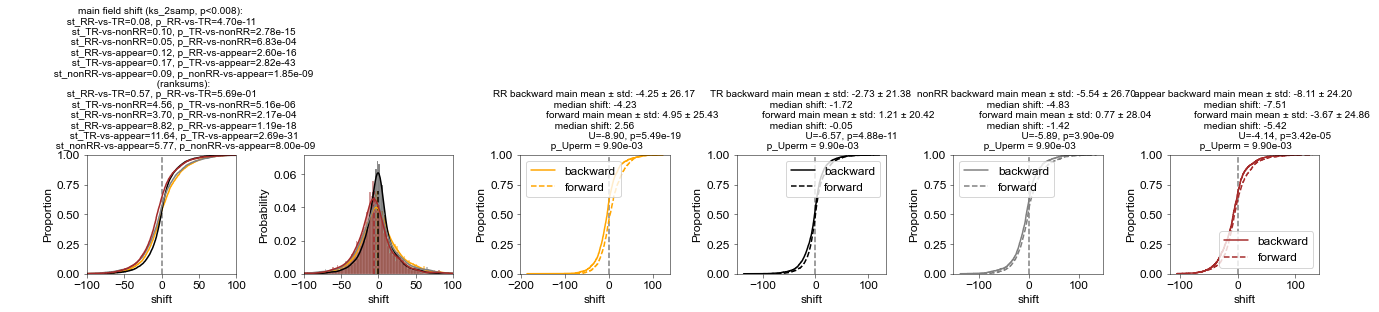

In [28]:
# Primary (main) field shifts, backwards vs. forward switches
# Ext Fig. 3o, stats for  Ext Fig. 3p

# fig, ax = plt.subplots(len(ct_keys),8,figsize=(28,12))
fig2, ax2 = plt.subplots(1, len(ct_keys)+2, figsize=(18, 4.5))
n_shuf = 100

print('-- primary field shifts, backwards vs. forward --')
for ct_i, ct in enumerate(['RR', 'TR', 'nonRR', 'appear']):
    if ct == "RR":
        vcolor = "orange"
    elif ct == "TR":
        vcolor = "black"
    elif ct == "nonRR":
        vcolor = "grey"
    elif ct == "appear":
        vcolor = "brown"

    shift_df_ct = shift_df[shift_df['ct'] == ct]

    sns.ecdfplot(data=shift_df_ct[(shift_df_ct['is_main_field'])],
        x='shift',
            stat="proportion",
            legend=True,
            ax=ax2[0],
            color=vcolor,
        )

    sns.histplot(data=shift_df_ct[(shift_df_ct['is_main_field'])],
                 ax=ax2[1], stat="probability",
                     x="shift", kde=True, binwidth=2, binrange=(-100, 100),
                     color=vcolor,
                     # element="bars",
                )
    ax2[1].vlines(shift_df_ct[(shift_df_ct['is_main_field'])]['shift'].median(),
                             0, 0.05, color=vcolor, linestyle='--');

    # compare backward and forward shifts of main field
    backward = shift_df_ct[(shift_df_ct['is_main_field']) &
                (shift_df_ct['switch_dir'] == 'backward')]['shift']
    forward = shift_df_ct[(shift_df_ct['is_main_field']) &
                (shift_df_ct['switch_dir'] == 'forward')]['shift']
    print(ct, 'n_backward:', len(backward), 'n_forward', len(forward))
    sns.ecdfplot(data=shift_df_ct[(shift_df_ct['is_main_field']) &
                                  (shift_df_ct['switch_dir'] == 'backward')],
        x='shift',
            stat="proportion",
            legend=True,
            ax=ax2[ct_i+2],
            color=vcolor,
                 label='backward'
        )
    sns.ecdfplot(data=shift_df_ct[(shift_df_ct['is_main_field']) &
                                  (shift_df_ct['switch_dir'] == 'forward')],
        x='shift',
            stat="proportion",
            legend=True,
            ax=ax2[ct_i+2],
            color=vcolor,
                 linestyle='--',
                 label='forward'
        )
    st_dir, p_dir = sp.stats.ranksums(
    backward,
    forward,
    )

    # permutation test for switch direction
    Z_shuf = np.zeros((n_shuf, 2))
    for n in range(n_shuf):
        switch_dir_shuffle = np.copy(shift_df_ct['switch_dir'].values)
        np.random.shuffle(switch_dir_shuffle)
        shift_df_ct['switch_dir_shuffle'] = switch_dir_shuffle
        backward_shuf = shift_df_ct[(shift_df_ct['is_main_field']) &
                        (shift_df_ct['switch_dir_shuffle'] == 'backward')]['shift']
        forward_shuf = shift_df_ct[(shift_df_ct['is_main_field']) &
                    (shift_df_ct['switch_dir_shuffle'] == 'forward')]['shift']

        Z_shuf[n, 0], Z_shuf[n, 1] = sp.stats.ranksums(
        backward_shuf,
        forward_shuf,
        )
    p_perm = ut.permutation_test(Z_shuf[:, 0], st_dir)

    ax2[ct_i+2].set_title('%s backward main mean ± std: %.2f ± %.2f \n median shift: %.2f \n \
                           forward main mean ± std: %.2f ± %.2f \n median shift: %.2f \n \
                             U=%.2f, p=%.2e \n p_Uperm = %.2e'
                             % (ct,
            backward.mean(),
            backward.std(),
            backward.median(),
            forward.mean(),
            forward.std(),
            forward.median(),
                                st_dir,
                                p_dir,
                                p_perm
                            ), fontsize = 10)
    ax2[ct_i+2].vlines(0, 0, 1, color = 'grey', linestyle = '--')
    ax2[ct_i+2].legend()

# ks
st_RRTR_ks, p_RRTR_ks=sp.stats.ks_2samp(
    shift_df[(shift_df['ct'] == 'RR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'TR') & (shift_df['is_main_field'])]['shift'],
)
# print(st_RRTR, p_RRTR)
st_TRnonRR_ks, p_TRnonRR_ks=sp.stats.ks_2samp(
    shift_df[(shift_df['ct'] == 'TR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'nonRR') & (
        shift_df['is_main_field'])]['shift'],
)
# print(st_TRnonRR, p_TRnonRR)
st_RRnonRR_ks, p_RRnonRR_ks=sp.stats.ks_2samp(
    shift_df[(shift_df['ct'] == 'RR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'nonRR') & (
        shift_df['is_main_field'])]['shift'],
)
# print(st_RRnonRR, p_RRnonRR)
st_RRappear_ks, p_RRappear_ks=sp.stats.ks_2samp(
    shift_df[(shift_df['ct'] == 'RR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'appear') & (
        shift_df['is_main_field'])]['shift'],
)
st_TRappear_ks, p_TRappear_ks=sp.stats.ks_2samp(
    shift_df[(shift_df['ct'] == 'TR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'appear') & (
        shift_df['is_main_field'])]['shift'],
)
st_nonRRappear_ks, p_nonRRappear_ks=sp.stats.ks_2samp(
    shift_df[(shift_df['ct'] == 'nonRR') & (
        shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'appear') & (
        shift_df['is_main_field'])]['shift'],
)

# ranksums

st_RRTR, p_RRTR=sp.stats.ranksums(
    shift_df[(shift_df['ct'] == 'RR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'TR') & (shift_df['is_main_field'])]['shift'],
)
# print(st_RRTR, p_RRTR)
st_TRnonRR, p_TRnonRR=sp.stats.ranksums(
    shift_df[(shift_df['ct'] == 'TR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'nonRR') & (
        shift_df['is_main_field'])]['shift'],
)
# print(st_TRnonRR, p_TRnonRR)
st_RRnonRR, p_RRnonRR=sp.stats.ranksums(
    shift_df[(shift_df['ct'] == 'RR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'nonRR') & (
        shift_df['is_main_field'])]['shift'],
)
# print(st_RRnonRR, p_RRnonRR)

st_RRappear, p_RRappear=sp.stats.ranksums(
    shift_df[(shift_df['ct'] == 'RR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'appear') & (
        shift_df['is_main_field'])]['shift'],
)
st_TRappear, p_TRappear=sp.stats.ranksums(
    shift_df[(shift_df['ct'] == 'TR') & (shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'appear') & (
        shift_df['is_main_field'])]['shift'],
)
st_nonRRappear, p_nonRRappear=sp.stats.ranksums(
    shift_df[(shift_df['ct'] == 'nonRR') & (
        shift_df['is_main_field'])]['shift'],
    shift_df[(shift_df['ct'] == 'appear') & (
        shift_df['is_main_field'])]['shift'],
)

ax2[0].vlines(0, 0, 1, color = 'grey', linestyle = '--')
ax2[0].set_xlim([-100, 100])
ax2[1].set_xlim([-100, 100])


ax2[0].set_title(
    "main field shift (ks_2samp, p<%.3f): \n st_RR-vs-TR=%.2f, p_RR-vs-TR=%.2e \n \
                st_TR-vs-nonRR=%.2f, p_TR-vs-nonRR=%.2e \n \
                st_RR-vs-nonRR=%.2f, p_RR-vs-nonRR=%.2e \n \
                st_RR-vs-appear=%.2f, p_RR-vs-appear=%.2e \n \
                st_TR-vs-appear=%.2f, p_TR-vs-appear=%.2e \n \
                st_nonRR-vs-appear=%.2f, p_nonRR-vs-appear=%.2e \n \
                (ranksums): \n st_RR-vs-TR=%.2f, p_RR-vs-TR=%.2e \n \
                st_TR-vs-nonRR=%.2f, p_TR-vs-nonRR=%.2e \n \
                st_RR-vs-nonRR=%.2f, p_RR-vs-nonRR=%.2e \n \
                st_RR-vs-appear=%.2f, p_RR-vs-appear=%.2e \n \
                st_TR-vs-appear=%.2f, p_TR-vs-appear=%.2e \n \
                st_nonRR-vs-appear=%.2f, p_nonRR-vs-appear=%.2e"
    % ((0.05/6),
       st_RRTR_ks,
        p_RRTR_ks,
        st_TRnonRR_ks,
        p_TRnonRR_ks,
        st_RRnonRR_ks,
        p_RRnonRR_ks,
       st_RRappear_ks,
        p_RRappear_ks,
        st_TRappear_ks,
        p_TRappear_ks,
        st_nonRRappear_ks,
        p_nonRRappear_ks,
        st_RRTR,
        p_RRTR,
        st_TRnonRR,
        p_TRnonRR,
        st_RRnonRR,
        p_RRnonRR,
       st_RRappear,
        p_RRappear,
        st_TRappear,
        p_TRappear,
        st_nonRRappear,
        p_nonRRappear,

    ),
    fontsize=10,
)
save_figures=False
if save_figures:
    pt.savefig(
        fig2,
        fig_dir,
        "%s_days%s_%s_fieldShift_cdf-by-celltype_nstd%d_ntrials%d"
        % (
            ut.make_anim_tag(include_ans),
            ut.make_day_tag(exp_days),
            "-".join([ct for ct in ct_keys]),
            n_std,
            n_trials_thr,
        ),
        extension=".svg",
    )

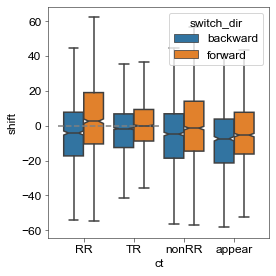

In [29]:
# boxplot for ED fig. 3p, to accompany stats printed out above on the celltype cdfs

fig, ax=plt.subplots(figsize = (4, 4))

sns.boxplot(data = shift_df[shift_df['is_main_field']],
               x = 'ct', y = 'shift',
             ax=ax,  dodge=True, showfliers=False,  notch=True,
            hue='switch_dir', hue_order=['backward', 'forward'],
            
              )
              # palette={'RR':'orange', 'TR': 'black', 'nonRR': 'grey'})
ax.hlines(0,-0.5,1.5,color='grey',linestyle='--')
save_figures = False
if save_figures:
    pt.savefig(
        fig,
        fig_dir,
        "%s_days%s_%s_MAINfieldShift-by-dir_boxplot_nstd%d_ntrials%d_corrected"
        % (
            ut.make_anim_tag(include_ans),
            ut.make_day_tag(exp_days),
            "-".join([ct for ct in ct_keys]),
            n_std,
            n_trials_thr,
        ),
        extension=".svg",
    )

-- primary vs secondary field shifts (both dir) --
RR 0.11562286049620187 1.3054524672373446e-07
TR 0.048925155177871126 0.0007232488758152078
nonRR 0.10613313642112053 1.1499690089067371e-11
appear 0.1724882771071747 2.220446049250313e-15


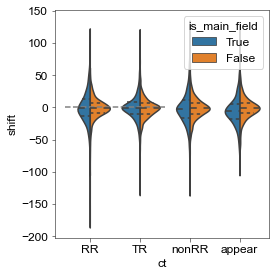

In [30]:
# violin plot for Ext Fig. 3n 

fig, ax = plt.subplots(figsize=(4, 4))
sns.violinplot(data=shift_df,
               x='ct', y='shift',
               ax=ax,  split=True,
               inner="quart",
               gap=.1, cut=0,
               hue='is_main_field', hue_order=[True, False],
              )

print('-- primary vs secondary field shifts (both dir) --')
for ct in ct_keys:
    shift_df_ct = shift_df[shift_df['ct'] == ct]
    primary_data = shift_df_ct['shift'][(shift_df_ct['is_main_field'])]
    sec_data = shift_df_ct['shift'][(shift_df_ct['is_main_field'] == False)]

    st_ks, p_ks = sp.stats.ks_2samp(
    primary_data,
    sec_data,
    )

    print(ct, st_ks, p_ks)

ax.hlines(0, -0.5, 1.5, color='grey', linestyle='--')
save_figures = False
if save_figures:
    pt.savefig(
        fig,
        fig_dir,
        "%s_days%s_%s_fieldShift-by-main-field_violins_nstd%d_ntrials%d_corrected"
        % (
            ut.make_anim_tag(include_ans),
            ut.make_day_tag(exp_days),
            "-".join([ct for ct in ct_keys]),
            n_std,
            n_trials_thr,
        ),
        extension = ".svg",
    )

    

In [287]:
# ut.write_source_csv(shift_df[shift_df['is_main_field']], "Ext3p")
# ut.write_source_csv(shift_df, "Ext3n")

writing /data/2P/source_data/FigExt3p.csv
writing /data/2P/source_data/FigExt3n.csv


______________________

## Saving and loading

In [290]:
# save pickle
from datetime import datetime
timestr = datetime.now().strftime("%Y%m%d-%H%M")
pkl_name = 'allSwitchAns_days%s_%s_SuperFieldDict_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), timestr)
save_ds = open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "wb")
dill.dump(super_field_dict, save_ds)

In [ ]:
pkl_name = 'allSwitchAns_days%s_%s_ShiftDf_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), timestr)
save_df = open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "wb")
pickle.dump(shift_df, save_df)

In [ ]:
# Load
ct_keys = ['RR','TR','nonRR','appear']

dt = '20240807-1121'
pkl_name = 'allSwitchAns_days%s_%s_SuperFieldDict_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), dt)

super_field_dict = dill.load(open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "rb"))


pkl_df_name = 'allSwitchAns_days%s_%s_ShiftDf_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), dt)
shift_df = dill.load(open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_df_name), "rb"))


In [ ]:
shift_df